# 📘 Actividad 1 — Predicción del comportamiento del cliente

## *Estrategia del Dato: Machine Learning y Deep Learning*

---

### 📋 Datos del alumno

| Campo | Valor |
|---|---|
| **Nombre y apellidos** | Hugo Onaindia de Celis |
| **Fecha de entrega** | 19/5/26 |
| **Titulación** | *Psicologo* |
| **Email UNIR** | *hugo.onaindiade6398@comunidadunir.net* |

---

### 🎯 Resumen de la actividad

Vamos a construir un **modelo de Machine Learning** capaz de predecir si una **reserva de la cadena hotelera Palladium será cancelada o no**, a partir de un conjunto de variables del cliente y de la propia reserva.

El dataset que utilizarás es **`palladium_reservas.csv`** y contiene unos **1.000 registros** con información de clientes, hoteles, fechas, precios e historial de reservas.

### 🧭 Fases que tendrás que cubrir
1. **Carga y exploración inicial** del dataset.
2. **Análisis exploratorio (EDA)** — el bloque más importante.
3. **Preprocesamiento** — limpieza de nulos, outliers, duplicados, codificación de variables.
4. **División en train / test**.
5. **Selección, entrenamiento y evaluación** del modelo.
6. **Ajuste de hiperparámetros**.
7. **Interpretación de resultados y conclusiones**.

### ⚠️ Lo que más se va a valorar

> 🔍 **La justificación de tus decisiones**, no solo la ejecución del código.
> En cada fase encontrarás **celdas de texto en blanco** donde tendrás que **explicar el porqué** de lo que has hecho. Esa parte pesa más que el propio código.

---


## 0. 📚 Importación de librerías

Importa todas las librerías que vayas a necesitar a lo largo de la actividad. Como mínimo: manipulación de datos, gráficos, métricas y modelos.


In [1]:
# 👉 Importa aquí todas las librerías que vayas a usar.
#    Sugerencias: pandas, numpy, matplotlib, seaborn, sklearn.
#    Recuerda usar los alias habituales (pd, np, plt, sns).
# import ...
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split





---

## 1. 📂 Carga del dataset y exploración inicial

Carga el archivo `palladium_reservas.csv` y haz una primera inspección para entender qué tienes entre manos: dimensiones, columnas, tipos de datos, distribución del target, etc.

> 💡 *Hay varias funciones de Pandas que te dan una visión rápida del dataset… piensa en cuáles.*


# Nueva sección

In [2]:
# 1.1 Carga el CSV en un DataFrame llamado, por ejemplo, df.
df=pd.read_csv('palladium_reservas.csv')
# df = pd.read_csv(...)


In [3]:
# 1.2 Inspecciona el dataset:
#     - dimensiones (filas, columnas)
print(df.shape)

(1010, 20)


In [4]:
#primeras filas
df.head(5) #devuelve las 5 primeras filas.

,ID_Reserva,Edad,Genero,Pais,Hotel,Tipo_Habitacion,Regimen,Canal_Reserva,Lead_Time_Dias,Mes_Llegada,Noches,Adultos,Ninos,Precio_Noche_EUR,Reservas_Previas,Cancelaciones_Previas,Tiene_Parking,Peticiones_Especiales,Tipo_Deposito,Cancelado
0,100001,36.0,Female,España,Palladium Mallorca,Standard,Desayuno,Agencia online,77.0,6,4,2,0,134.64,3,2,Sí,0.0,Reembolsable,0
1,100002,24.0,Male,Francia,Palladium Mallorca,Junior Suite,Desayuno,Web directa,7.0,9,3,1,0,NaN,1,0,NO,0.0,Sin depósito,0
2,100003,46.0,Male,España,Palladium Riviera Maya,Standard,Todo incluido,Web directa,64.0,8,14,2,3,142.04,7,1,Sí,0.0,Sin depósito,1
3,100004,42.0,Male,Países Bajos,Palladium Mallorca,Standard,Desayuno,Walk-in,3.0,4,3,2,0,160.59,1,1,Sí,2.0,Sin depósito,0
4,100005,61.0,Female,EEUU,Palladium Costa Mujeres,Standard,Todo incluido,Web directa,34.0,8,2,2,0,150.49,1,0,Sí,0.0,No reembolsable,0


In [5]:
df.tail(5)#devuelve las ultimas 5 filas

,ID_Reserva,Edad,Genero,Pais,Hotel,Tipo_Habitacion,Regimen,Canal_Reserva,Lead_Time_Dias,Mes_Llegada,Noches,Adultos,Ninos,Precio_Noche_EUR,Reservas_Previas,Cancelaciones_Previas,Tiene_Parking,Peticiones_Especiales,Tipo_Deposito,Cancelado
1005,100409,18.0,Male,Países Bajos,Palladium Ibiza,Junior Suite,Todo incluido,Agencia online,29.0,8,4,1,2,204.49,1,0,No,0.0,Reembolsable,1
1006,100813,45.0,Male,España,Palladium Tenerife,Junior Suite,Desayuno,Agencia online,30.0,7,4,1,2,290.66,0,0,Sí,4.0,No reembolsable,0
1007,100095,44.0,Female,Reino Unido,Palladium Riviera Maya,Standard,Todo incluido,Agencia tradicional,13.0,11,5,2,2,90.08,3,0,No,0.0,Sin depósito,0
1008,100488,44.0,Male,España,Palladium Tenerife,Standard,Desayuno,Agencia online,6.0,9,1,1,0,151.63,0,0,Sí,0.0,Sin depósito,0
1009,100171,34.0,Female,Francia,Palladium Punta Cana,Standard,Desayuno,Walk-in,5.0,10,5,3,2,92.17,0,0,No,1.0,Reembolsable,0


In [6]:
#tipos de datos y nulos
df.info()#parece que no hay datos nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID_Reserva             1010 non-null   int64  
 1   Edad                   970 non-null    float64
 2   Genero                 1010 non-null   object 
 3   Pais                   980 non-null    object 
 4   Hotel                  1010 non-null   object 
 5   Tipo_Habitacion        1010 non-null   object 
 6   Regimen                1010 non-null   object 
 7   Canal_Reserva          1010 non-null   object 
 8   Lead_Time_Dias         959 non-null    float64
 9   Mes_Llegada            1010 non-null   int64  
 10  Noches                 1010 non-null   int64  
 11  Adultos                1010 non-null   int64  
 12  Ninos                  1010 non-null   int64  
 13  Precio_Noche_EUR       950 non-null    float64
 14  Reservas_Previas       1010 non-null   int64  
 15  Canc

In [7]:
#estadisticas descriptivas categoricas y numericas
df.describe()#estadisticas numericas


,ID_Reserva,Edad,Lead_Time_Dias,Mes_Llegada,Noches,Adultos,Ninos,Precio_Noche_EUR,Reservas_Previas,Cancelaciones_Previas,Peticiones_Especiales,Cancelado
count,1010.000000,970.000000,959.000000,1010.000000,1010.000000,1010.000000,1010.000000,950.000000,1010.000000,1010.000000,980.000000,1010.000000
mean,100499.883168,43.207216,56.037539,6.711881,4.999010,1.982178,0.584158,260.576621,1.491089,0.262376,1.121429,0.174257
std,288.602618,15.183547,54.778379,2.718938,2.844674,0.700898,0.861779,612.823267,1.288210,0.526287,1.300016,0.379519
min,100001.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,27.450000,0.000000,0.000000,0.000000,0.000000
25%,100250.250000,34.000000,17.000000,5.000000,3.000000,2.000000,0.000000,116.057500,1.000000,0.000000,0.000000,0.000000
50%,100498.500000,43.000000,39.000000,7.000000,4.000000,2.000000,0.000000,165.870000,1.000000,0.000000,1.000000,0.000000
75%,100750.750000,52.000000,77.000000,8.000000,6.000000,2.000000,1.000000,261.680000,2.000000,0.000000,2.000000,0.000000
max,101000.000000,220.000000,386.000000,12.000000,14.000000,4.000000,3.000000,12000.000000,9.000000,4.000000,5.000000,1.000000


In [8]:

df.describe(include='object')#estadisticas categoricas


,Genero,Pais,Hotel,Tipo_Habitacion,Regimen,Canal_Reserva,Tiene_Parking,Tipo_Deposito
count,1010,980,1010,1010,1010,1010,970,990
unique,4,10,6,4,4,5,4,3
top,Male,España,Palladium Ibiza,Standard,Todo incluido,Web directa,No,Sin depósito
freq,496,281,207,530,344,421,608,521


In [9]:
# 1.3 Estudia la variable objetivo 'Cancelado':
#     - ¿cuántas clases tiene?
#     - ¿cómo está distribuida?
#     - ¿hay desbalanceo?



In [10]:
df['Cancelado'].value_counts()#contabilizamos la variable cancelado

,count
Cancelado,
0,834
1,176


In [11]:
df['Cancelado'].nunique()#cuantas clases tiene .arriba se ve que 0 y 1

2

In [12]:
df['Cancelado'].value_counts(normalize=True)#te da la proporcion de cancelaciones un 17% aprox

,proportion
Cancelado,
0,0.825743
1,0.174257


### ❓ Pregunta 1 — Primera impresión del dataset

Tras esta inspección inicial:
- ¿Cuántas filas y columnas tiene el dataset?
1010 filas y 20 columnas
- ¿Cómo está distribuida la variable objetivo? ¿Hay desbalanceo de clases?
de forma desigual , 80/20
- ¿Qué columnas crees que pueden ser más relevantes para predecir la cancelación y por qué?
Probablemente las cancelaciones previas

> ✏️ Tu respuesta

Habria que ver la relacion entre todas las variables, puede que el sexo influya y las mujeres sean mas responsables y cancelen menos o que los que cancelan habitualmente tiendan a llevar ese patron.Si las reservas se hacen con mucha antelacion o muy poca...etc


---

## 2. 🎨 Análisis Exploratorio de Datos (EDA)

🚩 **Esta es la fase con más peso de toda la actividad.** Aquí se valora especialmente la **profundidad** de tu análisis y **lo que extraigas de los gráficos**, no la cantidad de gráficos.

Genera al menos los siguientes tipos de visualizaciones (puedes añadir más si lo crees necesario):
- Distribución del **target** y comprobación del balanceo de clases.
- Distribución de **variables numéricas** (histogramas, boxplots…).
- Distribución de **variables categóricas** (gráficos de barras / sectores).
- **Relación entre variables y el target** (qué variables parecen influir más en la cancelación).
- **Mapa de correlaciones** entre variables numéricas.

> 💡 *Cada gráfico que pongas debe responder a una pregunta. Si no se te ocurre la pregunta, probablemente ese gráfico sobra.*


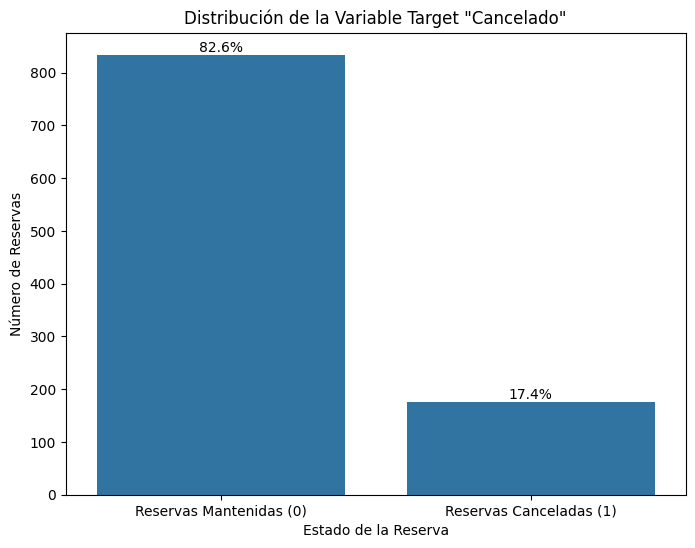

In [13]:
# 2.1 Análisis del balanceo de la variable objetivo.
#     Elige un gráfico que muestre claramente si las clases están equilibradas o no.

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Cancelado', data=df)
plt.title('Distribución de la Variable Target "Cancelado"')
plt.xlabel('Estado de la Reserva')
plt.ylabel('Número de Reservas')
plt.xticks([0, 1], ['Reservas Mantenidas (0)', 'Reservas Canceladas (1)'])

total = len(df['Cancelado'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()
# El gráfico muestra la gran descompensación entre cancelaciones y no cancelaciones,con porcentajes.

### ❓ Pregunta 2 — Balanceo de clases

- ¿Qué gráfico has elegido para visualizar el balanceo del target? ¿Por qué?
- ¿Existe desbalanceo? Si sí, **¿qué consecuencias puede tener** sobre la elección del modelo y, sobre todo, sobre la **elección de métricas** que vas a usar más adelante?



He elegido un conteo de cuantas reservas se han mantenido vs cancelaciones para mostrar el desequilibrio en el target.se ve de un vistazo la gran diferencia que hay.
Hay un gran desvalanceo y el modelo va a tender a predecir mantenimiento de las reservas porque la mayoria se mantienen y tiene mas posibilidades de acertar.Hay que elegir un modelo que no se vea tan afectado por este tipo de ditribuciones,un moidelo tipo random forest seria adecuado.



In [14]:
# 2.2 Distribuciones de las variables NUMÉRICAS.
#     Histogramas, boxplots o lo que consideres adecuado.
#     Fíjate en posibles outliers y formas de las distribuciones.



In [15]:
#vamos a ver las variables numericas

In [16]:
df.select_dtypes(include=np.number).describe()

,ID_Reserva,Edad,Lead_Time_Dias,Mes_Llegada,Noches,Adultos,Ninos,Precio_Noche_EUR,Reservas_Previas,Cancelaciones_Previas,Peticiones_Especiales,Cancelado
count,1010.000000,970.000000,959.000000,1010.000000,1010.000000,1010.000000,1010.000000,950.000000,1010.000000,1010.000000,980.000000,1010.000000
mean,100499.883168,43.207216,56.037539,6.711881,4.999010,1.982178,0.584158,260.576621,1.491089,0.262376,1.121429,0.174257
std,288.602618,15.183547,54.778379,2.718938,2.844674,0.700898,0.861779,612.823267,1.288210,0.526287,1.300016,0.379519
min,100001.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,27.450000,0.000000,0.000000,0.000000,0.000000
25%,100250.250000,34.000000,17.000000,5.000000,3.000000,2.000000,0.000000,116.057500,1.000000,0.000000,0.000000,0.000000
50%,100498.500000,43.000000,39.000000,7.000000,4.000000,2.000000,0.000000,165.870000,1.000000,0.000000,1.000000,0.000000
75%,100750.750000,52.000000,77.000000,8.000000,6.000000,2.000000,1.000000,261.680000,2.000000,0.000000,2.000000,0.000000
max,101000.000000,220.000000,386.000000,12.000000,14.000000,4.000000,3.000000,12000.000000,9.000000,4.000000,5.000000,1.000000


### Histograma de la variable Edad

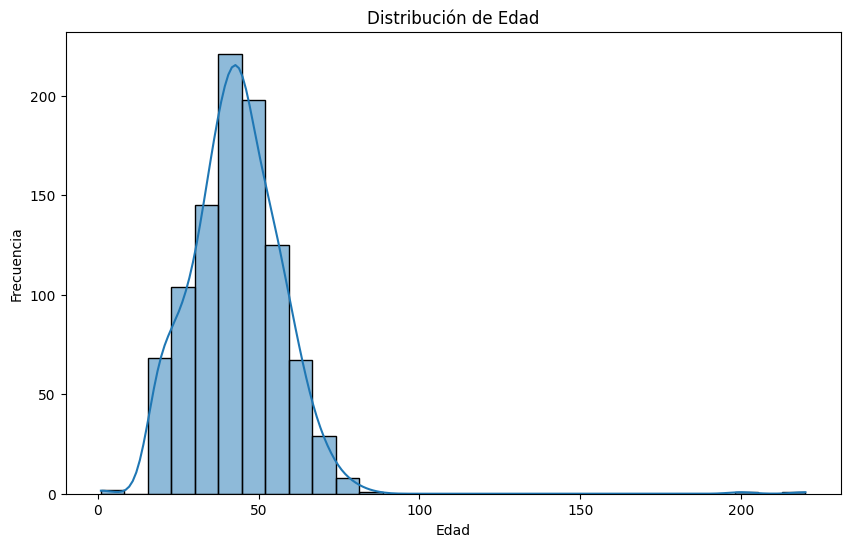

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Edad'], kde=True, bins=30)
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

### Histograma de la variable precio por noche

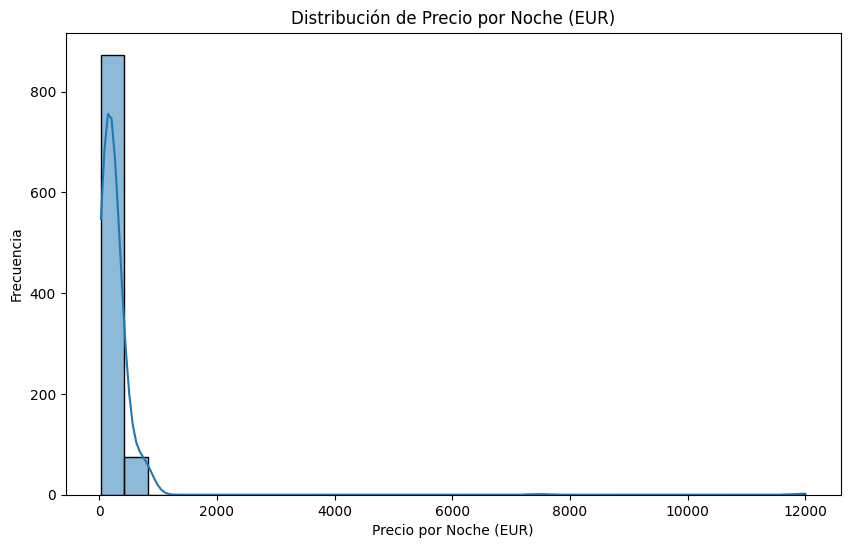

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Precio_Noche_EUR'], kde=True, bins=30)
plt.title('Distribución de Precio por Noche (EUR)')
plt.xlabel('Precio por Noche (EUR)')
plt.ylabel('Frecuencia')
plt.show()

### Comparación de 'Edad' y 'Cancelado'

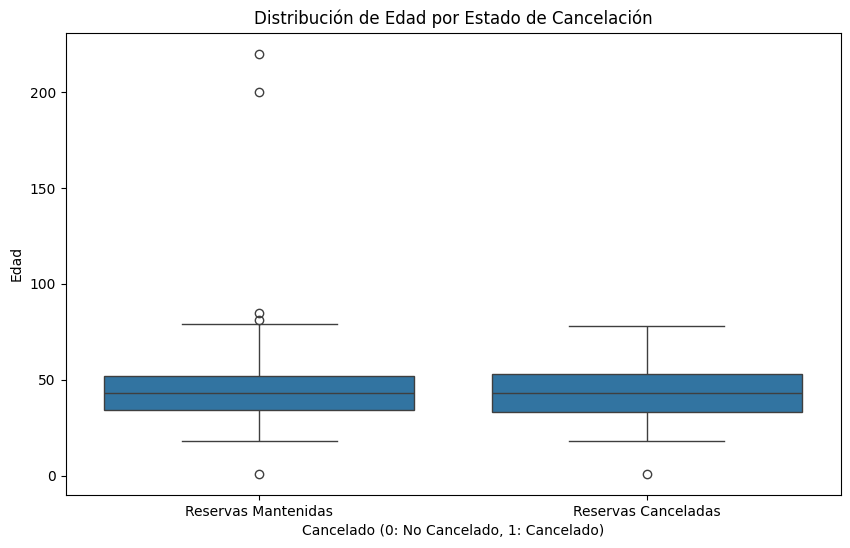

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cancelado', y='Edad', data=df)
plt.title('Distribución de Edad por Estado de Cancelación')
plt.xlabel('Cancelado (0: No Cancelado, 1: Cancelado)')
plt.ylabel('Edad')
plt.xticks([0, 1], ['Reservas Mantenidas', 'Reservas Canceladas'])
plt.show()

### Relación entre 'Edad' y 'Cancelado' (Probabilidad de Cancelación)

### Distribución de 'Edad' comparada por estado de 'Cancelado'

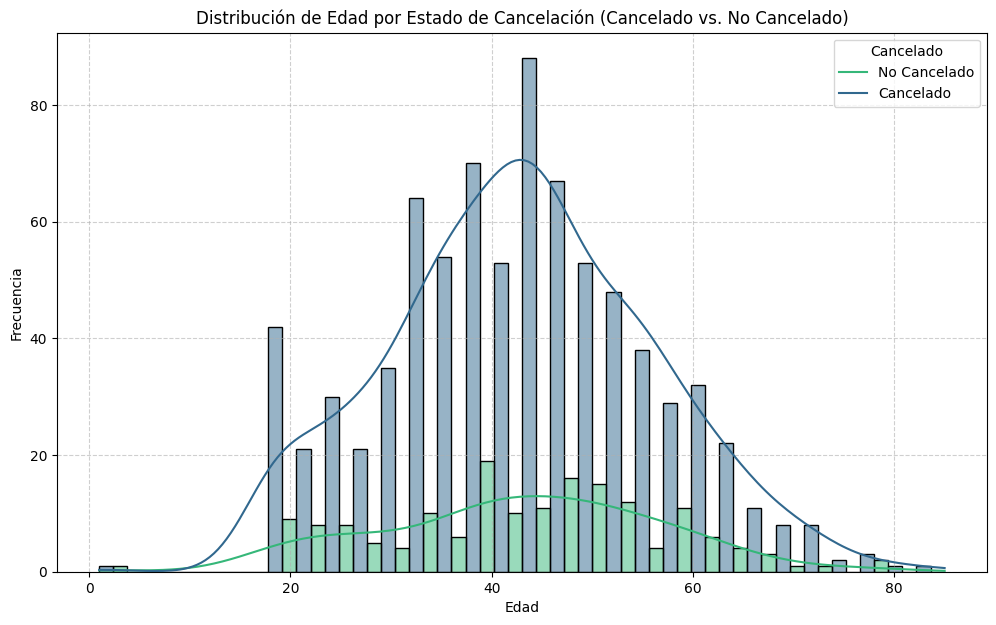

In [20]:
# Filtramos los valores extremos de 'Edad' (e.g., Edad < 100) para una mejor visualización
df_filtered_age = df[df['Edad'] < 100].copy()

plt.figure(figsize=(12, 7))
sns.histplot(data=df_filtered_age, x='Edad', hue='Cancelado', multiple='dodge', bins=30, kde=True, palette='viridis')
plt.title('Distribución de Edad por Estado de Cancelación (Cancelado vs. No Cancelado)')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend(title='Cancelado', labels=['No Cancelado', 'Cancelado'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


El precio por noche no parece discriminar mucho, la edad si puede ser mas interesante para estudiar.Hay errores en la variable edad salvo jordi hurtado nadie vive 200 años.Si podemos ver que entre los 20 y los 40 hay mas pero no es muy util porque las cancelaciones mayoritarias estan en la media de edad del cliente del hotel.

### Proporción de Cancelaciones por Grupos de Edad

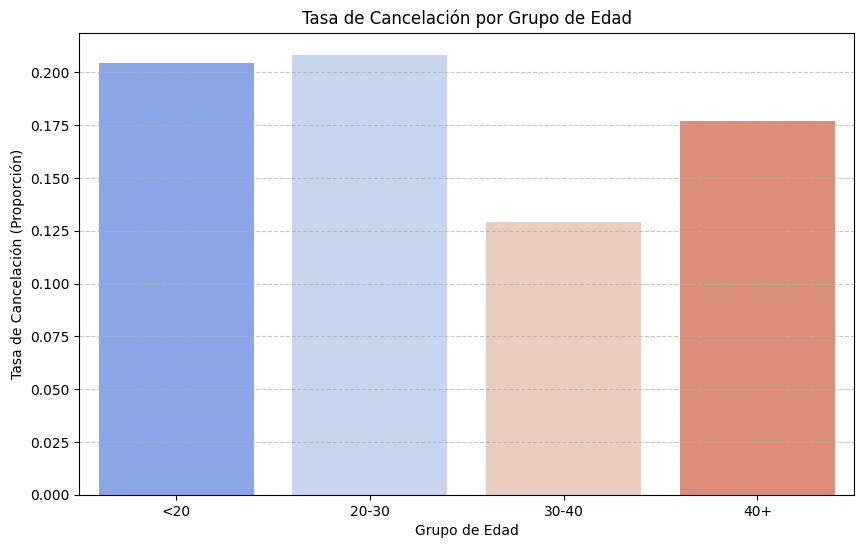

In [21]:
bins = [0, 20, 30, 40, 100]
labels = ['<20', '20-30', '30-40', '40+']

# Usamos el DataFrame filtrado para evitar el outlier de 220 años
df_filtered_age['Grupo_Edad'] = pd.cut(df_filtered_age['Edad'], bins=bins, labels=labels, right=False)

cancellation_by_age_group = df_filtered_age.groupby('Grupo_Edad', observed=False)['Cancelado'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Grupo_Edad', y='Cancelado', data=cancellation_by_age_group, palette='coolwarm', hue='Grupo_Edad', legend=False)
plt.title('Tasa de Cancelación por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Tasa de Cancelación (Proporción)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Tasa de Cancelación por Tipo de Depósito

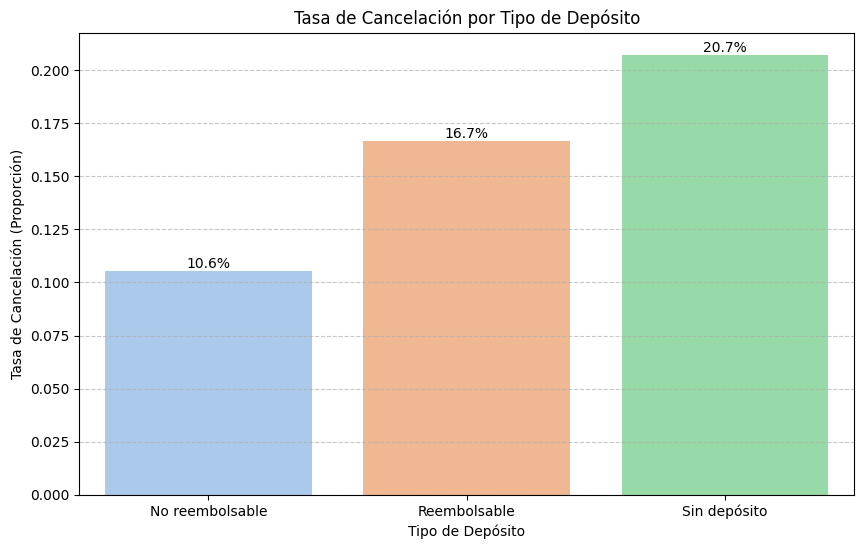

In [22]:
cancellation_by_deposit_type = df.groupby('Tipo_Deposito')['Cancelado'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Tipo_Deposito', y='Cancelado', data=cancellation_by_deposit_type, palette='pastel', hue='Tipo_Deposito', legend=False)
plt.title('Tasa de Cancelación por Tipo de Depósito')
plt.xlabel('Tipo de Depósito')
plt.ylabel('Tasa de Cancelación (Proporción)')

# Añadir porcentajes a las barras
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Aqui si que podemos ver que el grupo de 30-40 es el que menos cancela.Y que el tipo de deposito influye mucho.los depositos no reeenvolsables se cancelan mucho menos, esto puede servir al hotel para plantear politicas de cancelacion mas duras.sin reeenvolso.

### Tasa de Cancelación por Número de Cancelaciones Previas

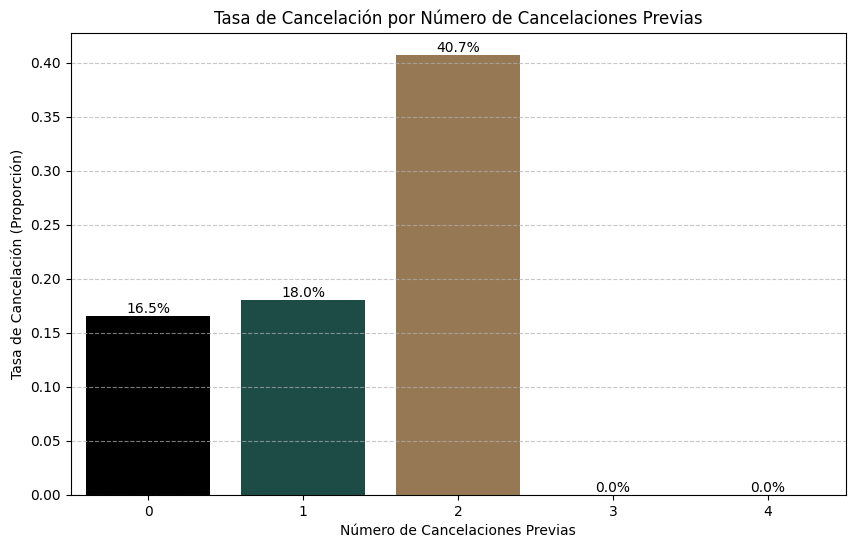

In [23]:
cancellation_by_prev_cancellations = df.groupby('Cancelaciones_Previas', observed=False)['Cancelado'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Cancelaciones_Previas', y='Cancelado', data=cancellation_by_prev_cancellations, palette='cubehelix', hue='Cancelaciones_Previas', legend=False)
plt.title('Tasa de Cancelación por Número de Cancelaciones Previas')
plt.xlabel('Número de Cancelaciones Previas')
plt.ylabel('Tasa de Cancelación (Proporción)')

# Añadir porcentajes a las barras
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Se ve muy claramente que la probabilidad aumenta muchisimo a partir de 2 cancelaciones,con lo cual los clientes que tengan 2 o mas cancelaciones preevias hay mucha probabilidad de que cancelen.el hotel puede poner las habitaciones como disponibles con menos riesgo.

In [24]:
# 2.3 Distribuciones de las variables CATEGÓRICAS.
#     ¿Hay categorías muy minoritarias? ¿Hay categorías mal escritas?



### Identificación y Conteo de Variables Categóricas

In [25]:
# Identificar variables categóricas (excluyendo 'ID_Reserva' si se considera solo un identificador)
categorical_cols = df.select_dtypes(include='object').columns

print("Variables categóricas y su número de valores únicos:")
for col in categorical_cols:
    print(f"- {col}: {df[col].nunique()} valores únicos")
    if df[col].nunique() < 20: # Mostrar top 10 si no hay demasiados únicos
        print(df[col].value_counts().head(10))
    print("\n")

Variables categóricas y su número de valores únicos:
- Genero: 4 valores únicos
Genero
Male      496
Female    489
FEMALE     13
male       12
Name: count, dtype: int64


- Pais: 10 valores únicos
Pais
España          281
Reino Unido     153
Francia         100
EEUU             88
Alemania         87
México           73
Italia           69
Países Bajos     64
Portugal         33
Argentina        32
Name: count, dtype: int64


- Hotel: 6 valores únicos
Hotel
Palladium Ibiza            207
Palladium Riviera Maya     196
Palladium Mallorca         185
Palladium Punta Cana       167
Palladium Tenerife         131
Palladium Costa Mujeres    124
Name: count, dtype: int64


- Tipo_Habitacion: 4 valores únicos
Tipo_Habitacion
Standard        530
Junior Suite    254
Suite           159
Villa            67
Name: count, dtype: int64


- Regimen: 4 valores únicos
Regimen
Todo incluido       344
Desayuno            318
Media pensión       205
Solo alojamiento    143
Name: count, dtype: int64


- Ca

Parece que en la variable parking hay probleemas porque es case sensitive. esta pasando lo mismo con sexo, mayusculas y minusculas.Habria que normalizar

### Distribución de la Variable Categórica 'Pais'

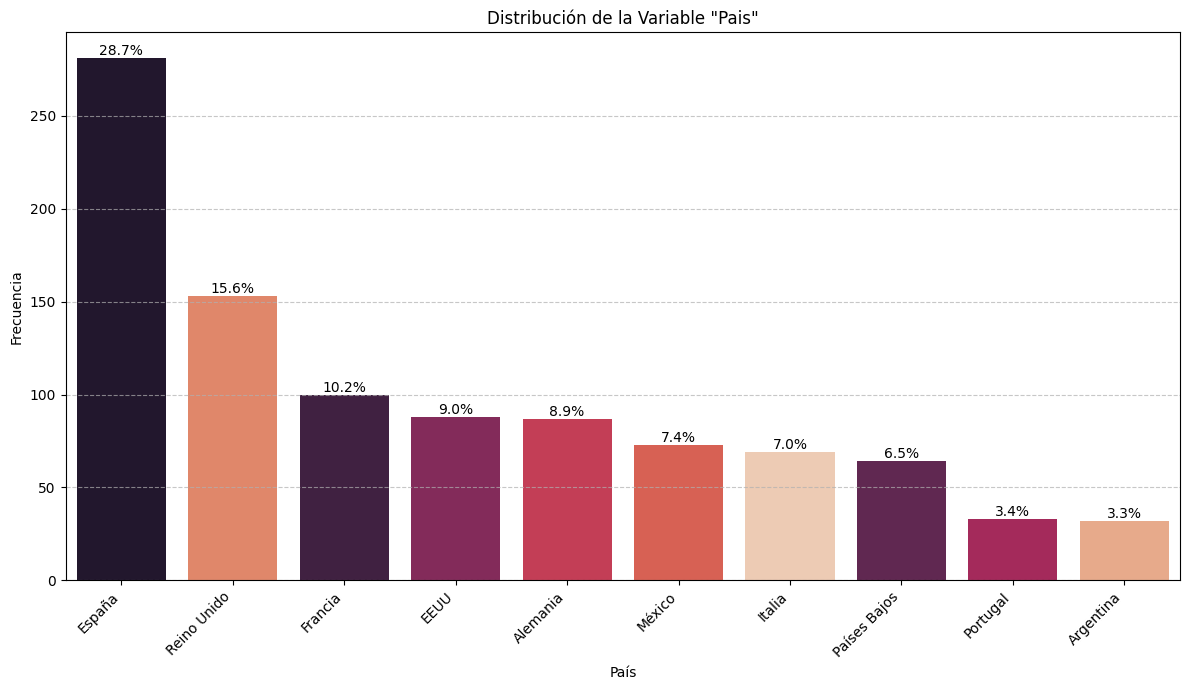

In [26]:
plt.figure(figsize=(12, 7))
ax = sns.countplot(x='Pais', data=df, order=df['Pais'].value_counts().index, palette='rocket', hue='Pais', legend=False)
plt.title('Distribución de la Variable "Pais"')
plt.xlabel('País')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right') # Rotar etiquetas para mejor lectura

# Añadir porcentajes a las barras
total = len(df['Pais'].dropna()) # Contar solo valores no nulos para el total
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Ajustar el diseño para evitar recortes
plt.show()

La variable pais muestra que argentina y portugal son dos categorias muy minoritarias.

In [27]:
# 2.4 Relación de cada variable con el target 'Cancelado'.
#     Compara, por ejemplo, las cancelaciones por hotel, canal de reserva,
#     tipo de depósito, lead time, precio, etc.



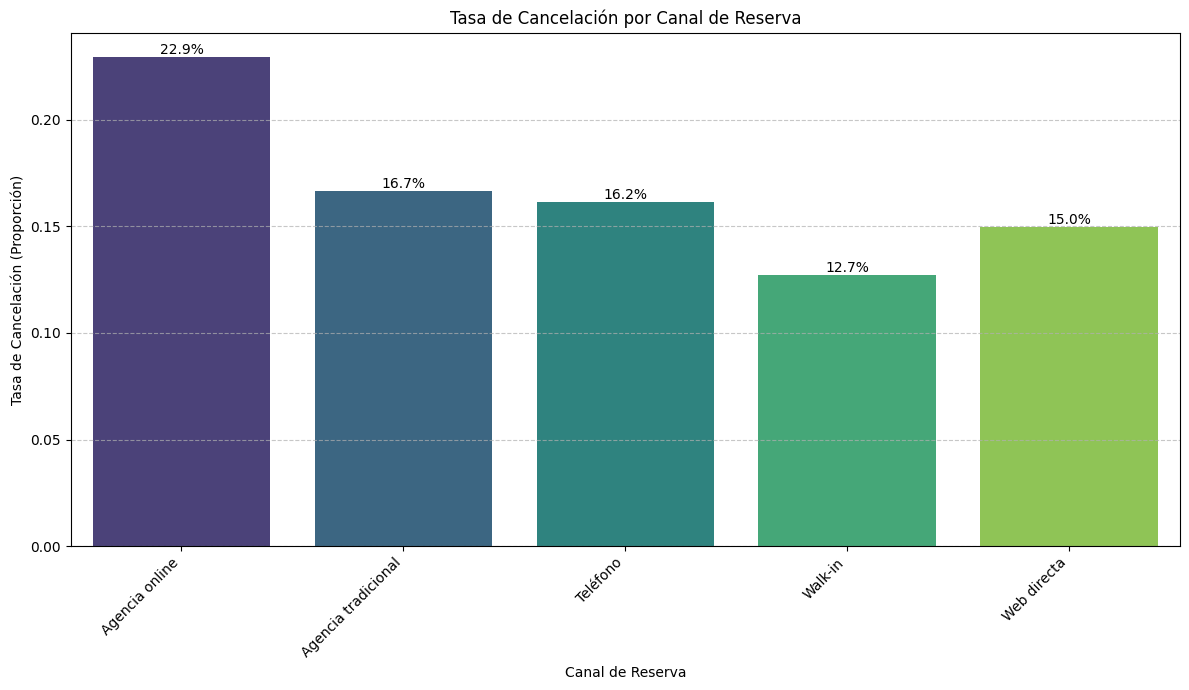

In [28]:
cancellation_by_channel = df.groupby('Canal_Reserva', observed=False)['Cancelado'].mean().reset_index()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Canal_Reserva', y='Cancelado', data=cancellation_by_channel, palette='viridis', hue='Canal_Reserva', legend=False)
plt.title('Tasa de Cancelación por Canal de Reserva')
plt.xlabel('Canal de Reserva')
plt.ylabel('Tasa de Cancelación (Proporción)')

# Añadir porcentajes a las barras
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

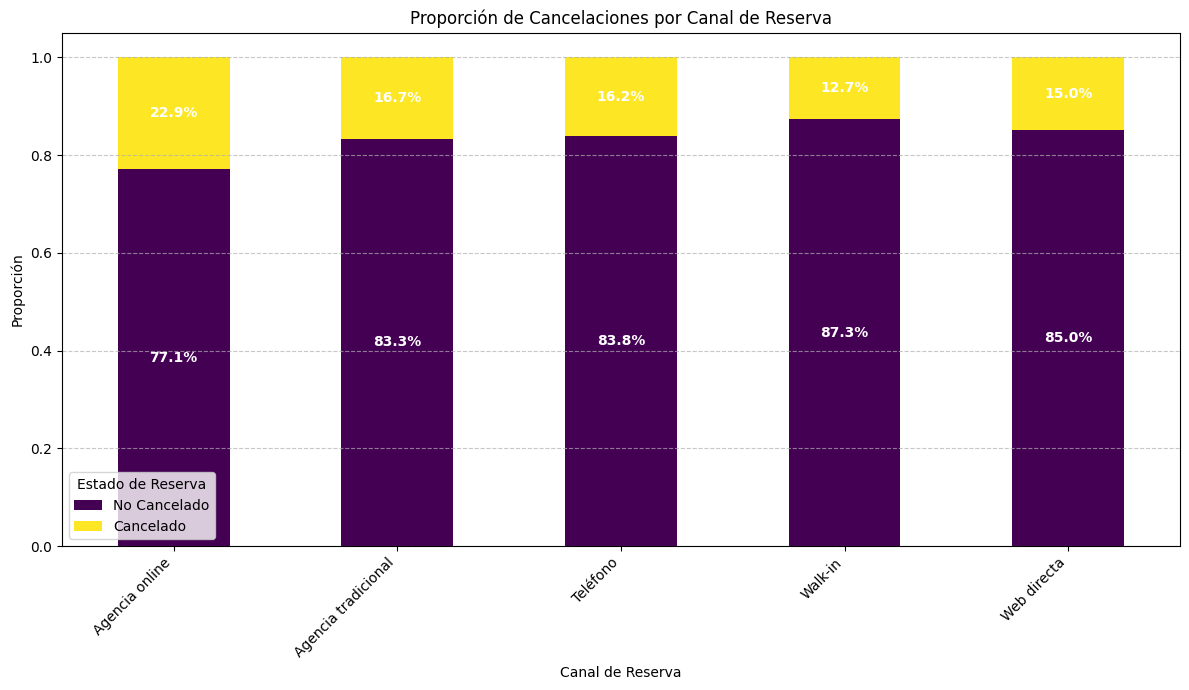

In [29]:
channel_cancellations = df.groupby('Canal_Reserva', observed=False)['Cancelado'].value_counts(normalize=True).unstack().fillna(0)

# Rename columns for better legend labels
channel_cancellations.columns = ['No Cancelado', 'Cancelado']

plt.figure(figsize=(12, 7))
ax = channel_cancellations.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())

plt.title('Proporción de Cancelaciones por Canal de Reserva')
plt.xlabel('Canal de Reserva')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Estado de Reserva')

# Añadir porcentajes a las barras
for container in ax.containers:
    for p in container.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_x(), p.get_y()
        if height > 0: # Only label if there is a segment
            ax.annotate(f'{height:.1%}', (x + width / 2, y + height / 2),
                        ha='center', va='center', color='white', weight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

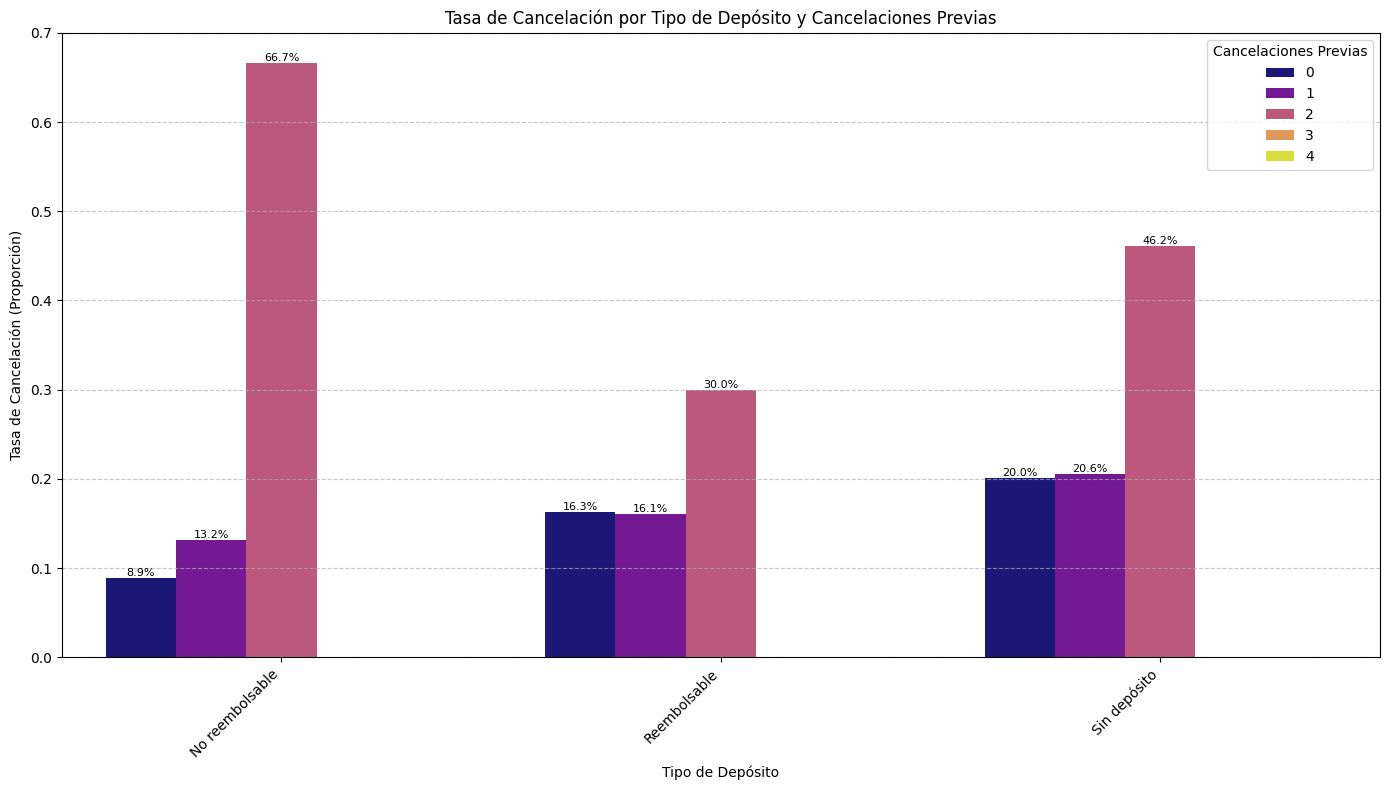

In [30]:
cancellation_deposit_prev = df.groupby(['Tipo_Deposito', 'Cancelaciones_Previas'], observed=False)['Cancelado'].mean().reset_index()

plt.figure(figsize=(14, 8))
sns.barplot(x='Tipo_Deposito', y='Cancelado', hue='Cancelaciones_Previas', data=cancellation_deposit_prev, palette='plasma')
plt.title('Tasa de Cancelación por Tipo de Depósito y Cancelaciones Previas')
plt.xlabel('Tipo de Depósito')
plt.ylabel('Tasa de Cancelación (Proporción)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cancelaciones Previas')

# Añadir porcentajes a las barras
for container in plt.gca().containers:
    for p in container.patches:
        height = p.get_height()
        if height > 0:
            plt.gca().annotate(f'{height:.1%}',
                               (p.get_x() + p.get_width() / 2, p.get_y() + height),
                               ha='center', va='bottom', fontsize=8, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Juntando dos variables conseguimos mucha discriminacion.

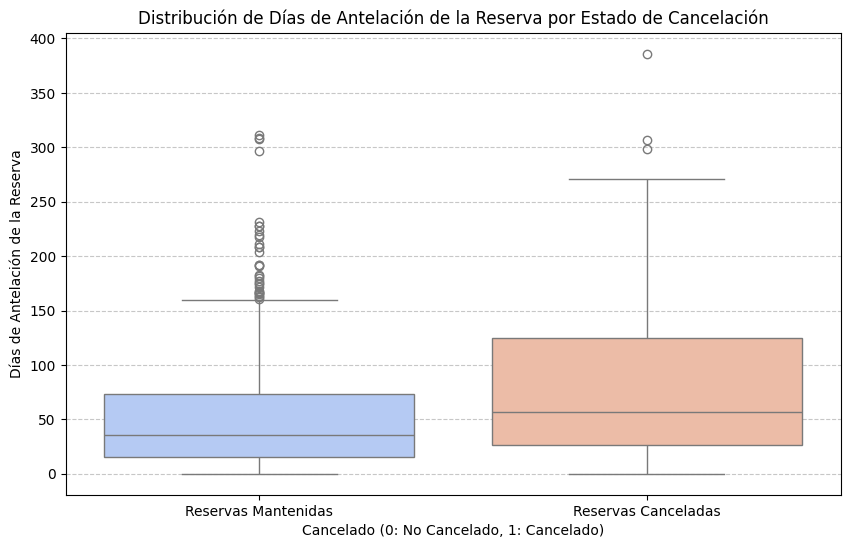

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cancelado', y='Lead_Time_Dias', data=df, palette='coolwarm', hue='Cancelado', legend=False)
plt.title('Distribución de Días de Antelación de la Reserva por Estado de Cancelación')
plt.xlabel('Cancelado (0: No Cancelado, 1: Cancelado)')
plt.ylabel('Días de Antelación de la Reserva')
plt.xticks([0, 1], ['Reservas Mantenidas', 'Reservas Canceladas'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

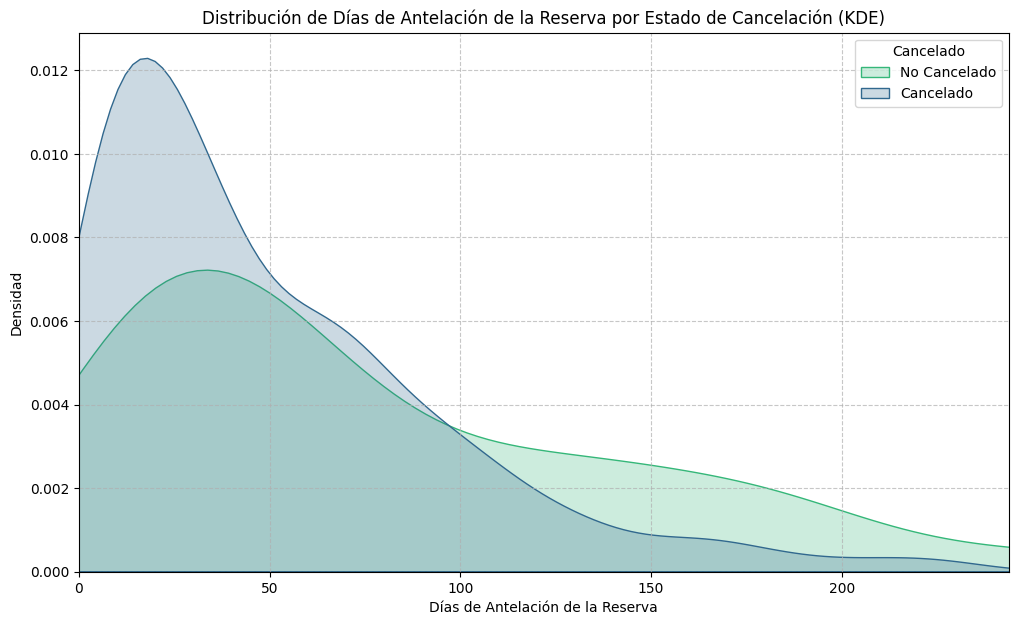

In [32]:
plt.figure(figsize=(12, 7))
sns.kdeplot(data=df, x='Lead_Time_Dias', hue='Cancelado', fill=True, common_norm=False, palette='viridis')
plt.title('Distribución de Días de Antelación de la Reserva por Estado de Cancelación (KDE)')
plt.xlabel('Días de Antelación de la Reserva')
plt.ylabel('Densidad')
plt.legend(title='Cancelado', labels=['No Cancelado', 'Cancelado'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, df['Lead_Time_Dias'].quantile(0.99)) # Limitar el eje X para mejor visualización, excluyendo valores extremos
plt.show()

Se ve la relacion entre dias de la reserva y la cancelacion.

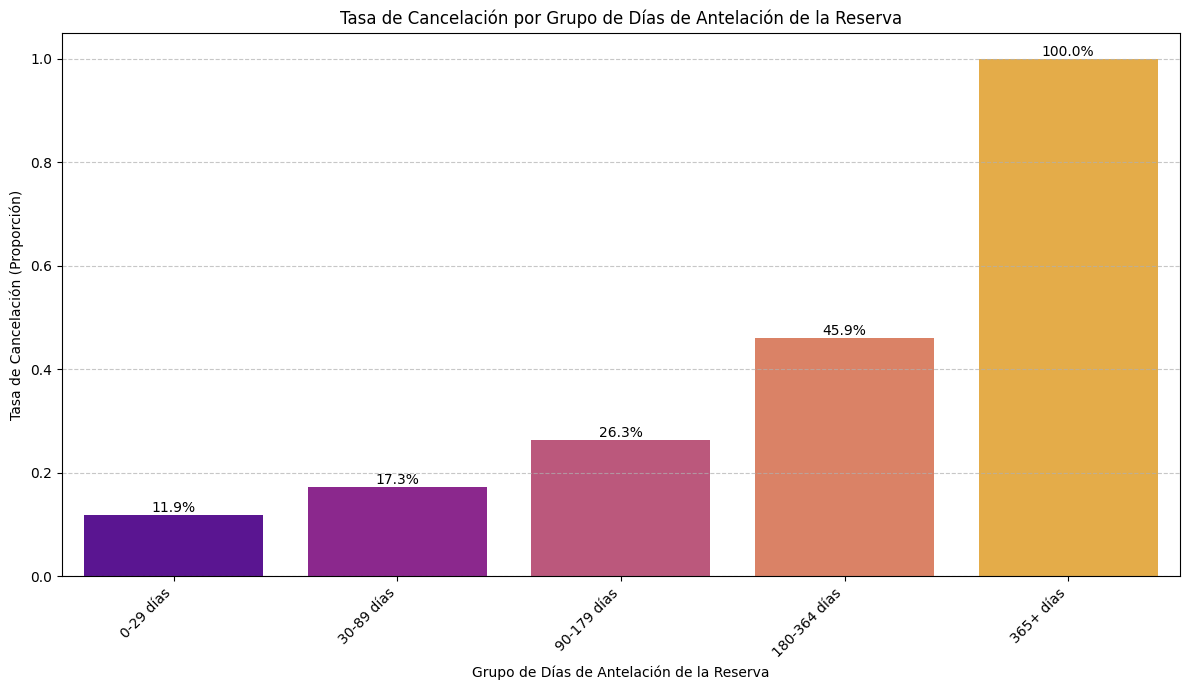

In [33]:
bins_lead_time = [0, 30, 90, 180, 365, df['Lead_Time_Dias'].max() + 1]
labels_lead_time = ['0-29 días', '30-89 días', '90-179 días', '180-364 días', '365+ días']

df['Lead_Time_Group'] = pd.cut(df['Lead_Time_Dias'], bins=bins_lead_time, labels=labels_lead_time, right=False)

cancellation_by_lead_time_group = df.groupby('Lead_Time_Group', observed=False)['Cancelado'].mean().reset_index()

plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Lead_Time_Group', y='Cancelado', data=cancellation_by_lead_time_group, palette='plasma', hue='Lead_Time_Group', legend=False)
plt.title('Tasa de Cancelación por Grupo de Días de Antelación de la Reserva')
plt.xlabel('Grupo de Días de Antelación de la Reserva')
plt.ylabel('Tasa de Cancelación (Proporción)')

# Add percentages to the bars
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Aqui se ve con mucha mas claridad la relacion

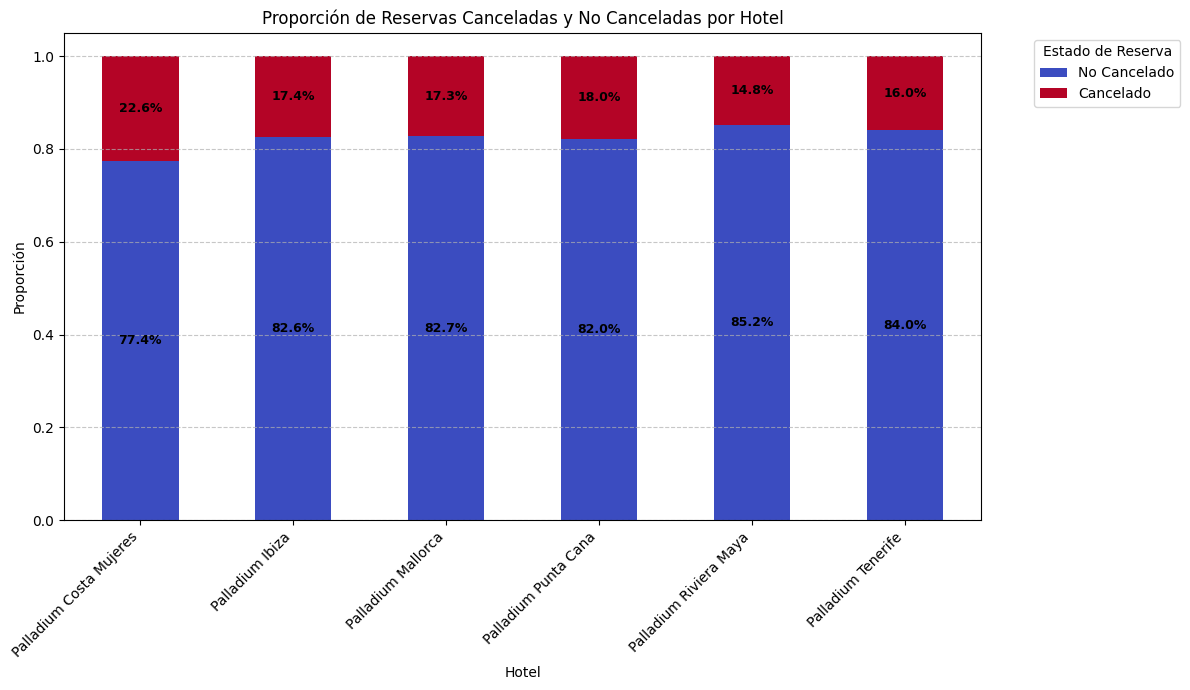

In [34]:
hotel_cancellations_proportion = df.groupby('Hotel', observed=False)['Cancelado'].value_counts(normalize=True).unstack().fillna(0)
hotel_cancellations_proportion.columns = ['No Cancelado', 'Cancelado']

plt.figure(figsize=(12, 7))
ax = hotel_cancellations_proportion.plot(kind='bar', stacked=True, colormap='coolwarm', ax=plt.gca())

plt.title('Proporción de Reservas Canceladas y No Canceladas por Hotel')
plt.xlabel('Hotel')
plt.ylabel('Proporción')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Estado de Reserva', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add percentages to the bars
for container in ax.containers:
    for p in container.patches:
        width, height = p.get_width(), p.get_height()
        x, y = p.get_x(), p.get_y()
        if height > 0.05: # Only label if the segment is large enough to be readable
            ax.annotate(f'{height:.1%}', (x + width / 2, y + height / 2),
                        ha='center', va='center', color='black', weight='bold', fontsize=9)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

No hay mucha diferencia, costa mujeres un poco mas

No comparo precio porque eel precio es muy uniforme y no creo que haya diferencias, las cancelaciones estaran distribuidas de forma muy parecida.

In [35]:
# 2.5 Matriz de correlación de las variables numéricas.



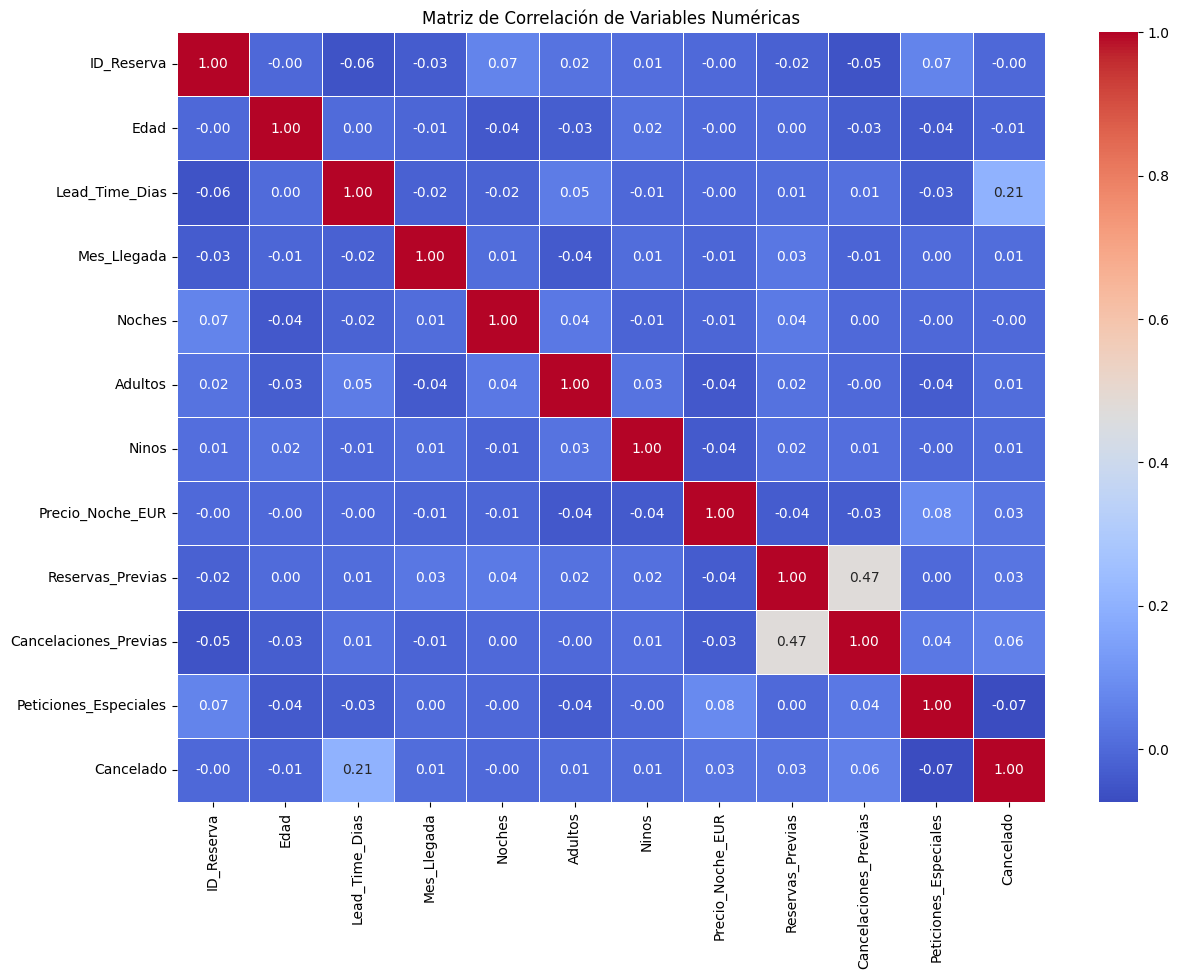

In [36]:
numerical_cols = df.select_dtypes(include=np.number).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [37]:
correlation_with_cancelled = correlation_matrix['Cancelado'].sort_values(ascending=False)
print("Variables numéricas con mayor correlación con 'Cancelado':")
print(correlation_with_cancelled)

Variables numéricas con mayor correlación con 'Cancelado':
Cancelado                1.000000
Lead_Time_Dias           0.205403
Cancelaciones_Previas    0.058659
Reservas_Previas         0.029532
Precio_Noche_EUR         0.028794
Ninos                    0.009661
Adultos                  0.007961
Mes_Llegada              0.007404
Noches                  -0.000758
ID_Reserva              -0.003207
Edad                    -0.013239
Peticiones_Especiales   -0.074166
Name: Cancelado, dtype: float64


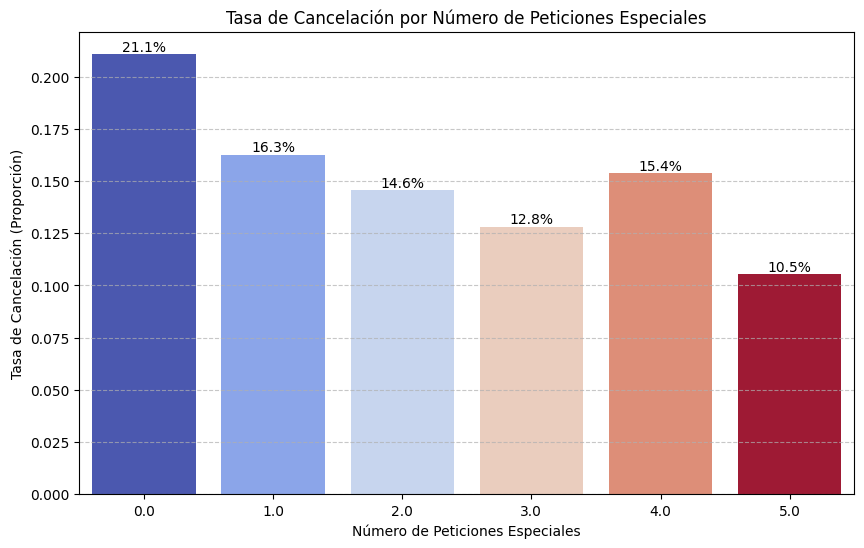

In [38]:
cancellation_by_special_requests = df.groupby('Peticiones_Especiales', observed=False)['Cancelado'].mean().reset_index()

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Peticiones_Especiales', y='Cancelado', data=cancellation_by_special_requests, palette='coolwarm', hue='Peticiones_Especiales', legend=False)
plt.title('Tasa de Cancelación por Número de Peticiones Especiales')
plt.xlabel('Número de Peticiones Especiales')
plt.ylabel('Tasa de Cancelación (Proporción)')

# Add percentages to the bars
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Detección de Outliers (Valores Atípicos) usando el método IQR

Vamos a identificar y mostrar los posibles outliers en las variables numéricas utilizando el método del Rango Intercuartílico (IQR). Veremos que valores estan en el 1/4 superior y el inferior asi vemos que valores hay alejados de los 2/4 del centro de la distribucion.

In [39]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'ID_Reserva' y 'Cancelado' si no son variables para análisis de outliers
exclude_cols = ['ID_Reserva', 'Cancelado']
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

print("--- Identificación de Outliers (Método IQR) ---")

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

    if not outliers.empty:
        print(f"\nOutliers detectados en la columna '{col}':")
        print(outliers.value_counts().sort_index())
    else:
        print(f"\nNo se detectaron outliers significativos en la columna '{col}'.")

--- Identificación de Outliers (Método IQR) ---

Outliers detectados en la columna 'Edad':
Edad
1.0      2
81.0     1
85.0     1
200.0    1
220.0    1
Name: count, dtype: int64

Outliers detectados en la columna 'Lead_Time_Dias':
Lead_Time_Dias
168.0    2
170.0    1
172.0    1
174.0    1
175.0    1
176.0    1
177.0    2
178.0    1
180.0    1
182.0    1
183.0    2
184.0    2
185.0    1
191.0    2
192.0    2
199.0    2
202.0    1
203.0    1
204.0    1
206.0    1
208.0    2
211.0    1
218.0    1
219.0    1
223.0    1
228.0    2
231.0    1
233.0    1
240.0    1
249.0    1
255.0    1
271.0    1
297.0    1
298.0    1
307.0    1
308.0    1
309.0    1
311.0    1
386.0    1
Name: count, dtype: int64

No se detectaron outliers significativos en la columna 'Mes_Llegada'.

Outliers detectados en la columna 'Noches':
Noches
14    42
Name: count, dtype: int64

Outliers detectados en la columna 'Adultos':
Adultos
1    209
3     95
4     48
Name: count, dtype: int64

Outliers detectados en la columna 

### ❓ Pregunta 3 — Hallazgos del EDA

Responde con detalle a las siguientes preguntas. **No te limites a describir gráficos**: explica qué te aporta cada hallazgo de cara al modelado.

- ¿Qué variables parecen tener más relación con la cancelación? ¿Por qué crees que es así desde el punto de vista del negocio hotelero?
- ¿Has detectado **outliers**? ¿En qué variables? ¿Crees que son errores reales o valores extremos legítimos?
- ¿Has detectado **inconsistencias** de formato (mayúsculas, espacios, categorías duplicadas)?
- ¿Hay alguna variable que, tras este análisis, te plantees **descartar**? ¿Por qué?


  Los dias desde la reserva y las cancelaciones previas parece que tienen mas relacion con la posterior cancelacion.Tiene todo el sentido ya que cuanto mas tiempo pasa mas cosas pueden pasar en tu vida que te hagan tener que cancelar.Y las personas que han cancelado muchas veces preeviamente es porque su vida tiene muchos imprevistos mas alla de que les devuelvan la reserva.
  Hay relacion entre si hay reenvolso o no pero dentro del grupo con muchas cancelaciones ya les da igual perder la reserva.
  Hay outliners en algunas variables como edad que clarmente son errores y otros valores que son atipicos como la gente que reserva con mucha anteelacion.Hay reeservas de 12000 euros que tienen que ser un error.En la columna edad puede haber gente dede 81 pero no de 200.Y en la de precios puede oscilar un poco pero no hasta los 12000.Hay inconsistencias en geneero y parking por el tema del case sensitive.Hay categorias duplicadas tambien por esto.Descartaria la ID de reeserva que no aporta nada.


---

## 3. 🧹 Preprocesamiento

Este es el otro bloque con más peso. Cada decisión que tomes aquí condiciona el resultado del modelo, así que **justifícalo todo**.

Vas a tener que tratar al menos:
1. **Duplicados**.
2. **Inconsistencias** en variables categóricas.
3. **Valores nulos**.
4. **Outliers**.
5. **Codificación de variables categóricas**.
6. **Escalado / normalización** (si tu modelo lo requiere).


### 3.1 Duplicados


In [40]:
# Detecta y elimina duplicados (si los hubiera).



In [41]:
df = pd.read_csv('palladium_reservas.csv')

print(f"Número de filas duplicadas antes de la eliminación: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Número de filas después de la eliminación de duplicados: {df.shape[0]}")

Número de filas duplicadas antes de la eliminación: 10
Número de filas después de la eliminación de duplicados: 1000


### 3.2 Limpieza de inconsistencias en variables categóricas

> 💡 *Algunas categorías pueden aparecer escritas con mayúsculas, espacios o en otro idioma. Decide cómo unificarlas.*


In [42]:
df['Genero'] = df['Genero'].astype(str).str.capitalize()
df['Genero'] = df['Genero'].replace({'Male': 'Masculino', 'Female': 'Femenino'})
print("Valores únicos en 'Genero' después de la normalización a español:")
print(df['Genero'].value_counts())

Valores únicos en 'Genero' después de la normalización a español:
Genero
Masculino    502
Femenino     498
Name: count, dtype: int64


Corregimos las mayusculas y minusculas y el idioma

In [43]:
# Normalizar la columna 'Tiene_Parking'
df['Tiene_Parking'] = df['Tiene_Parking'].astype(str).str.capitalize()
df['Tiene_Parking'] = df['Tiene_Parking'].replace({'Nan': np.nan})
df.dropna(subset=['Tiene_Parking'], inplace=True)
print("Valores únicos en 'Tiene_Parking' después de la normalización y eliminación de NaN:")
print(df['Tiene_Parking'].value_counts())

Valores únicos en 'Tiene_Parking' después de la normalización y eliminación de NaN:
Tiene_Parking
No    608
Sí    352
Name: count, dtype: int64


Aqui lo mismo, juntamos todos los valores y eliminamos los not a number

### 3.3 Valores nulos

Identifica las columnas con valores nulos y trátalos de la forma que consideres más adecuada para cada caso (no tiene por qué ser la misma estrategia en todas las columnas).


In [44]:
# Cuantifica nulos por columna y aplica la estrategia que decidas.



In [45]:
print('Número de nulos por columna:')
print(df.isnull().sum())

Número de nulos por columna:
ID_Reserva                0
Edad                     40
Genero                    0
Pais                     29
Hotel                     0
Tipo_Habitacion           0
Regimen                   0
Canal_Reserva             0
Lead_Time_Dias           48
Mes_Llegada               0
Noches                    0
Adultos                   0
Ninos                     0
Precio_Noche_EUR         59
Reservas_Previas          0
Cancelaciones_Previas     0
Tiene_Parking             0
Peticiones_Especiales    28
Tipo_Deposito            20
Cancelado                 0
dtype: int64


In [46]:
null_percentages = df.isnull().sum() / len(df) * 100
print("Porcentaje de valores nulos por columna:")
for col, percentage in null_percentages[null_percentages > 0].sort_values(ascending=False).items():
    print(f"{col:<25} {percentage:.2f}%")

Porcentaje de valores nulos por columna:
Precio_Noche_EUR          6.15%
Lead_Time_Dias            5.00%
Edad                      4.17%
Pais                      3.02%
Peticiones_Especiales     2.92%
Tipo_Deposito             2.08%


In [47]:
df['Edad'] = df['Edad'].fillna(df['Edad'].mean())
print(f"Nulos restantes en 'Edad': {df['Edad'].isnull().sum()}")

Nulos restantes en 'Edad': 0


La edad tiene una distribucion muy concreta de cuarentones y cincuentones y usar la media no afectara a los datos mucho ya que no es una variable clave y perderiamos info si eliminamos.

In [48]:
df['Lead_Time_Dias'] = df['Lead_Time_Dias'].fillna(df['Lead_Time_Dias'].mode()[0])
print(f"Nulos restantes en 'Lead_Time_Dias': {df['Lead_Time_Dias'].isnull().sum()}")

Nulos restantes en 'Lead_Time_Dias': 0


He decidido usar la moda porque habia valores muy dispersos de geente que reservaba con mucha antelacion y ddistorsionaria mucho la media.Usamos la sustitucion por lo mas frecuente y no perdemos datos

In [49]:
df['Pais'] = df['Pais'].fillna(df['Pais'].mode()[0])
print(f"Nulos restantes en 'Pais': {df['Pais'].isnull().sum()}")

Nulos restantes en 'Pais': 0


Usamos la moda tambien

In [50]:
df['Precio_Noche_EUR'] = df['Precio_Noche_EUR'].fillna(df['Precio_Noche_EUR'].mean())
print(f"Nulos restantes en 'Precio_Noche_EUR': {df['Precio_Noche_EUR'].isnull().sum()}")

Nulos restantes en 'Precio_Noche_EUR': 0


El precio por noche es muy parecido asi que con la media normalizamos.

In [51]:
df['Peticiones_Especiales'] = df['Peticiones_Especiales'].fillna(0)
print(f"Nulos restantes en 'Peticiones_Especiales': {df['Peticiones_Especiales'].isnull().sum()}")

Nulos restantes en 'Peticiones_Especiales': 0


Ponemos los valores nulos como 0 porque es un valor sensible y corto en rango como para haceer meedias o otras cosas.esta aproximacion me parerce la mas razonable para no perdeer sensibilidad con esta variable que mide un poco lo caprichosos que son los clieentes y es interesante.

In [52]:
df['Tipo_Deposito'] = df['Tipo_Deposito'].fillna(df['Tipo_Deposito'].mode()[0])
print(f"Nulos restantes en 'Tipo_Deposito': {df['Tipo_Deposito'].isnull().sum()}")

Nulos restantes en 'Tipo_Deposito': 0


In [53]:
bins_lead_time = [0, 30, 90, 180, 365, df['Lead_Time_Dias'].max() + 1]
labels_lead_time = ['0-29 días', '30-89 días', '90-179 días', '180-364 días', '365+ días']

df['Lead_Time_Group'] = pd.cut(df['Lead_Time_Dias'], bins=bins_lead_time, labels=labels_lead_time, right=False)

print("Verificando nulos después de re-crear 'Lead_Time_Group':")
print(df.isnull().sum()[df.isnull().sum() > 0])

Verificando nulos después de re-crear 'Lead_Time_Group':
Series([], dtype: int64)


Usamos moda para no añadir complicaciones

#### ❓ Pregunta 4 — Tratamiento de los nulos

- ¿En qué columnas hay nulos y en qué proporción?
- ¿Por qué crees que **existen** esos nulos? (¿son fallos técnicos? ¿el cliente no rellenó algo? ¿son nulos informativos?)
- ¿Qué estrategia has aplicado en cada columna (eliminación, media, mediana, moda, valor constante, modelado…) y por qué?
- ¿Has considerado **alternativas**? ¿Qué te ha hecho descartarlas?


> ✏️ Tu respuesta

*Escribe aquí tu justificación.*


### 3.4 Outliers

Decide qué hacer con los valores atípicos detectados durante el EDA.


In [54]:
# Aplica la técnica que consideres (IQR, Z-score, dominio del problema, etc.).



In [55]:
from scipy.stats import zscore

print("--- Identificación de Outliers (Método Z-score) ---")

# Recargar las columnas numéricas excluyendo 'ID_Reserva' y 'Cancelado'
numerical_cols_zscore = df.select_dtypes(include=np.number).columns.tolist()
exclude_cols_zscore = ['ID_Reserva', 'Cancelado']
numerical_cols_zscore = [col for col in numerical_cols_zscore if col not in exclude_cols_zscore]

for col in numerical_cols_zscore:
    # Eliminar NaNs temporales para el cálculo del zscore, si no se han tratado completamente
    # (aunque en este punto ya deberían estar tratados, es una buena práctica para la robustez)
    temp_series = df[col].dropna()
    if not temp_series.empty:
        z_scores = np.abs(zscore(temp_series))
        # Un umbral común para Z-score es 3 o -3 desviaciones estándar
        outliers_zscore = temp_series[z_scores > 3]

        if not outliers_zscore.empty:
            print(f"\nOutliers detectados en la columna '{col}' (Z-score > 3):")
            print(outliers_zscore.value_counts().sort_index())
        else:
            print(f"\nNo se detectaron outliers significativos en la columna '{col}' (Z-score > 3).")
    else:
        print(f"\nColumna '{col}' está vacía o solo contiene NaNs, no se puede calcular Z-score.")

--- Identificación de Outliers (Método Z-score) ---

Outliers detectados en la columna 'Edad' (Z-score > 3):
Edad
200.0    1
220.0    1
Name: count, dtype: int64

Outliers detectados en la columna 'Lead_Time_Dias' (Z-score > 3):
Lead_Time_Dias
223.0    1
228.0    2
231.0    1
233.0    1
240.0    1
249.0    1
255.0    1
271.0    1
297.0    1
298.0    1
307.0    1
308.0    1
309.0    1
311.0    1
386.0    1
Name: count, dtype: int64

No se detectaron outliers significativos en la columna 'Mes_Llegada' (Z-score > 3).

Outliers detectados en la columna 'Noches' (Z-score > 3):
Noches
14    42
Name: count, dtype: int64

No se detectaron outliers significativos en la columna 'Adultos' (Z-score > 3).

No se detectaron outliers significativos en la columna 'Ninos' (Z-score > 3).

Outliers detectados en la columna 'Precio_Noche_EUR' (Z-score > 3):
Precio_Noche_EUR
12000.0    2
Name: count, dtype: int64

Outliers detectados en la columna 'Reservas_Previas' (Z-score > 3):
Reservas_Previas
6    4
7

#### ❓ Pregunta 5 — Tratamiento de outliers

- ¿Qué técnica has elegido para identificar los outliers y por qué?
- ¿Los has **eliminado**, **transformado** o **mantenido**? Justifica tu decisión en función del contexto del problema (un precio de 12.000€ por noche en un hotel podría ser un error… o podría ser una villa real).


He elegido el rango intercuartilico porque deja fuera el cuarto superior e inferior.el z score mide lo que se aleja de la media el valor y tambien da una buena idea de la validez del valor.



In [56]:
Q1 = df['Precio_Noche_EUR'].quantile(0.25)
Q3 = df['Precio_Noche_EUR'].quantile(0.75)
IQR = Q3 - Q1

upper_bound_precio = Q3 + 1.5 * IQR

print(f"Upper bound for Precio_Noche_EUR (IQR method): {upper_bound_precio:.2f}")

initial_rows = df.shape[0]
df_filtered = df[df['Precio_Noche_EUR'] <= upper_bound_precio].copy()
rows_removed = initial_rows - df_filtered.shape[0]
df = df_filtered

print(f"Removed {rows_removed} rows with exaggerated room prices (above {upper_bound_precio:.2f} EUR).")
print(f"New DataFrame shape: {df.shape}")

Upper bound for Precio_Noche_EUR (IQR method): 458.64
Removed 64 rows with exaggerated room prices (above 458.64 EUR).
New DataFrame shape: (896, 21)


Elimino con la tecnica del rango intercuartilico los valores que claramente son outliners.Los valores no reflejan la realidad del ticket medio del hotel y no tiene mucho sentido incluirlos si no son representativos.Aunque hubiera una habitacion de 12000 es tan poco significativo que no merece la pena incluirlo para hacer predicciones.

In [57]:
initial_rows = df.shape[0]
df_cleaned_age = df[df['Edad'] <= 100].copy() # Assuming 100 is a reasonable upper limit for human age
rows_removed = initial_rows - df_cleaned_age.shape[0]
df = df_cleaned_age

print(f"Removed {rows_removed} rows where 'Edad' was above 100.")
print(f"New DataFrame shape: {df.shape}")

Removed 2 rows where 'Edad' was above 100.
New DataFrame shape: (894, 21)


Ya no aparecen edades de 200 años, se eliminan las que estan por encima de 100 que es lo realista.

### 3.5 Codificación de variables categóricas

Convierte tus variables categóricas a un formato que el modelo pueda usar.

> 💡 *Hay varias técnicas distintas (One-Hot, Label Encoding, Ordinal Encoding, Target Encoding…). Elige la que mejor se adapte a cada variable.*


In [58]:
# Codifica las variables categóricas con la técnica que decidas en cada caso.



In [59]:
categorical_cols_to_encode = ['Genero', 'Tiene_Parking']

# Aplicar One-Hot Encoding, eliminando la primera categoría para evitar la multicolinealidad
df = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

print("Primeras 5 filas del DataFrame después de One-Hot Encoding para Genero y Tiene_Parking:")
display(df.head())
print("Forma del DataFrame después de One-Hot Encoding:", df.shape)
print("Variables categóricas restantes (objetos) después de la codificación:")
print(df.select_dtypes(include='object').columns.tolist())

Primeras 5 filas del DataFrame después de One-Hot Encoding para Genero y Tiene_Parking:


,ID_Reserva,Edad,Pais,Hotel,Tipo_Habitacion,Regimen,Canal_Reserva,Lead_Time_Dias,Mes_Llegada,Noches,...,Ninos,Precio_Noche_EUR,Reservas_Previas,Cancelaciones_Previas,Peticiones_Especiales,Tipo_Deposito,Cancelado,Lead_Time_Group,Genero_Masculino,Tiene_Parking_Sí
0,100001,36.0,España,Palladium Mallorca,Standard,Desayuno,Agencia online,77.0,6,4,...,0,134.640000,3,2,0.0,Reembolsable,0,30-89 días,False,True
1,100002,24.0,Francia,Palladium Mallorca,Junior Suite,Desayuno,Web directa,7.0,9,3,...,0,255.271643,1,0,0.0,Sin depósito,0,0-29 días,True,False
2,100003,46.0,España,Palladium Riviera Maya,Standard,Todo incluido,Web directa,64.0,8,14,...,3,142.040000,7,1,0.0,Sin depósito,1,30-89 días,True,True
3,100004,42.0,Países Bajos,Palladium Mallorca,Standard,Desayuno,Walk-in,3.0,4,3,...,0,160.590000,1,1,2.0,Sin depósito,0,0-29 días,True,True
4,100005,61.0,EEUU,Palladium Costa Mujeres,Standard,Todo incluido,Web directa,34.0,8,2,...,0,150.490000,1,0,0.0,No reembolsable,0,30-89 días,False,True


Forma del DataFrame después de One-Hot Encoding: (894, 21)
Variables categóricas restantes (objetos) después de la codificación:
['Pais', 'Hotel', 'Tipo_Habitacion', 'Regimen', 'Canal_Reserva', 'Tipo_Deposito']


codifico con one hot las variables que solo tienen dos valores posibles ya que me parece lo mas logico y para las demas variables buscamos otros metodos.

In [60]:
categorical_cols_onehot = ['Pais', 'Hotel', 'Tipo_Habitacion', 'Regimen', 'Canal_Reserva', 'Tipo_Deposito']

df = pd.get_dummies(df, columns=categorical_cols_onehot, drop_first=True)

print("Primeras 5 filas del DataFrame después de One-Hot Encoding para las variables nominales:")
display(df.head())
print("Forma del DataFrame después de One-Hot Encoding:", df.shape)
print("Variables categóricas restantes (objetos) después de esta codificación:")
print(df.select_dtypes(include='object').columns.tolist())

Primeras 5 filas del DataFrame después de One-Hot Encoding para las variables nominales:


,ID_Reserva,Edad,Lead_Time_Dias,Mes_Llegada,Noches,Adultos,Ninos,Precio_Noche_EUR,Reservas_Previas,Cancelaciones_Previas,...,Tipo_Habitacion_Villa,Regimen_Media pensión,Regimen_Solo alojamiento,Regimen_Todo incluido,Canal_Reserva_Agencia tradicional,Canal_Reserva_Teléfono,Canal_Reserva_Walk-in,Canal_Reserva_Web directa,Tipo_Deposito_Reembolsable,Tipo_Deposito_Sin depósito
0,100001,36.0,77.0,6,4,2,0,134.640000,3,2,...,False,False,False,False,False,False,False,False,True,False
1,100002,24.0,7.0,9,3,1,0,255.271643,1,0,...,False,False,False,False,False,False,False,True,False,True
2,100003,46.0,64.0,8,14,2,3,142.040000,7,1,...,False,False,False,True,False,False,False,True,False,True
3,100004,42.0,3.0,4,3,2,0,160.590000,1,1,...,False,False,False,False,False,False,True,False,False,True
4,100005,61.0,34.0,8,2,2,0,150.490000,1,0,...,False,False,False,True,False,False,False,True,False,False


Forma del DataFrame después de One-Hot Encoding: (894, 41)
Variables categóricas restantes (objetos) después de esta codificación:
[]


In [61]:
from sklearn.preprocessing import OrdinalEncoder

# The 'labels_lead_time' list is assumed to be defined in previous cells with the correct order.
# For example: labels_lead_time = ['0-29 días', '30-89 días', '90-179 días', '180-364 días', '365+ días']

# Create an instance of the OrdinalEncoder with the defined order
ordinal_encoder = OrdinalEncoder(categories=[labels_lead_time], dtype=int)

# Apply ordinal encoding to 'Lead_Time_Group' and create a new column
df['Lead_Time_Group_Encoded'] = ordinal_encoder.fit_transform(df[['Lead_Time_Group']])

# Drop the original 'Lead_Time_Group' column as it's no longer needed
df = df.drop('Lead_Time_Group', axis=1)

print("Ordinal Encoding applied to 'Lead_Time_Group'.")
print("Shape of DataFrame after encoding:", df.shape)
print("Unique values and their counts for 'Lead_Time_Group_Encoded':")
print(df['Lead_Time_Group_Encoded'].value_counts().sort_index())

Ordinal Encoding applied to 'Lead_Time_Group'.
Shape of DataFrame after encoding: (894, 41)
Unique values and their counts for 'Lead_Time_Group_Encoded':
Lead_Time_Group_Encoded
0    391
1    331
2    136
3     35
4      1
Name: count, dtype: int64


#### ❓ Pregunta 6 — Codificación de categóricas

- ¿Qué técnica/s de codificación has usado y para qué variables?
- ¿Por qué esa técnica y no otra? Razónalo en función de:
  - el tipo de variable (nominal vs ordinal),
  - el número de categorías,
  - el modelo que piensas usar más adelante.


He usado one hot en las que solo hay dos posibles valores porque me parecia lo mas logico.con las demas variables he tenido mas dudas pero ordinal encoder podia confundir al modelo si no habia un orden.el modelo puede deducir relaciones de los numeros que le asignemos a las categoricas interpretando relaciones donde no hay.finalmente he aplicado one hot en todas las demas excepto en lead time group ya que tiene un orden natural y tiene sentido darle valores ordenados.
ordinal solo estaba lead time group



### 3.6 Escalado de variables numéricas (opcional según el modelo)

Algunos modelos son sensibles a la escala de los datos (Regresión Logística, SVM, KNN, redes neuronales) y otros no (árboles, random forest, XGBoost).


Voy a usar random forest por el tipo de distribucion en la que el 80% no se cancela y el 20 si.ademas da una salida bianaria, 1 o 0 o cancela o no que es lo ideal para lo que buscamos.puede encontrar relaciones complejas entre las variables.El modelo es comprensible con lo que se pueden aplicar las conclusiones a la mejora del negocio.

In [62]:
# Si tu modelo lo requiere, aplica un escalado/estandarización aquí.
#    Recuerda: AJUSTAR (fit) solo con el train, NUNCA con el test.



El random forest le da igual la magnitud y son arbolitos de decision no necesita estandarizacion.

#### ❓ Pregunta 7 — Escalado

- ¿Has decidido escalar las variables? ¿Sí / no / parcialmente?
- Justifica la decisión en función del modelo que vas a usar.


No he escalado variables porque este tipo de modelos funcionan bien sin escalado y no hay descenso de gradiente o valores outliners van a afectar mucho


---

## 4. ✂️ División del conjunto de datos

Separa los datos en entrenamiento y prueba.

> 💡 *Piensa en el % que reservas, en si conviene estratificar y en la `random_state` para que tus resultados sean reproducibles.*


In [63]:
# Realiza el split en X / y y luego en train / test.



In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

# Ensure 'Lead_Time_Group' is created (in case previous cells were run out of order)
bins_lead_time = [0, 30, 90, 180, 365, df['Lead_Time_Dias'].max() + 1]
labels_lead_time = ['0-29 días', '30-89 días', '90-179 días', '180-364 días', '365+ días']
# Re-create if it's not present, or if it was lost
if 'Lead_Time_Group' not in df.columns:
    df['Lead_Time_Group'] = pd.cut(df['Lead_Time_Dias'], bins=bins_lead_time, labels=labels_lead_time, right=False)
elif df['Lead_Time_Group'].dtype != 'category': # Ensure it's a categorical type if it exists
    df['Lead_Time_Group'] = pd.cut(df['Lead_Time_Dias'], bins=bins_lead_time, labels=labels_lead_time, right=False)

# Apply ordinal encoding to 'Lead_Time_Group'
ordinal_encoder = OrdinalEncoder(categories=[labels_lead_time], dtype=int)
df['Lead_Time_Group_Encoded'] = ordinal_encoder.fit_transform(df[['Lead_Time_Group']])

# Drop the original 'Lead_Time_Group' column as it's no longer needed, and 'ID_Reserva' for training
X = df.drop(['ID_Reserva', 'Cancelado', 'Lead_Time_Group'], axis=1)
y = df['Cancelado']

# Dividir los datos en conjuntos de entrenamiento (70%) y temporal (30%)
# Estratificamos 'y' para mantener la proporción de la clase 'Cancelado' debido al desbalanceo
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Dividir el conjunto temporal (30%) en validación (15%) y test (15%)
# Esto se logra dividiendo X_temp y y_temp a la mitad (0.5), ya que X_temp ya es el 30% del total.
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Tamaño de X_train: {X_train.shape}")
print(f"Tamaño de y_train: {y_train.shape}")
print(f"Tamaño de X_val: {X_val.shape}")
print(f"Tamaño de y_val: {y_val.shape}")
print(f"Tamaño de X_test: {X_test.shape}")
print(f"Tamaño de y_test: {y_test.shape}")

print("\nDistribución del target en los conjuntos:")
print("Train:")
print(y_train.value_counts(normalize=True))
print("Validation:")
print(y_val.value_counts(normalize=True))
print("Test:")
print(y_test.value_counts(normalize=True))

Tamaño de X_train: (625, 39)
Tamaño de y_train: (625,)
Tamaño de X_val: (134, 39)
Tamaño de y_val: (134,)
Tamaño de X_test: (135, 39)
Tamaño de y_test: (135,)

Distribución del target en los conjuntos:
Train:
Cancelado
0    0.8208
1    0.1792
Name: proportion, dtype: float64
Validation:
Cancelado
0    0.820896
1    0.179104
Name: proportion, dtype: float64
Test:
Cancelado
0    0.822222
1    0.177778
Name: proportion, dtype: float64


### ❓ Pregunta 8 — Estrategia de split

- ¿Qué proporción train/test has elegido y por qué?
- ¿Has aplicado **estratificación**? ¿Por qué (recuerda lo que viste en el balanceo de clases)?
- ¿Has considerado una **validación cruzada**? ¿En qué momento la aplicarás?


He elegido un split estricto de datos de 70,15,15 para que estemos seguros de que no se mezclan datos y se mantiene la proporcion de cancelaciones dada la naturaleza de la distribucion, hay una gran mayoria de reservas que se mantienen.Para que cada uno de los bloques de datos mantenga una proporcion de cancelaciones y reproduzca la distribucion original(80/20) estratificamos.
Vamos a aplicar tambien una validacion cruzada para sacar metricas de rendimiento del modelo.F1 , recall

In [65]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import numpy as np # Importar numpy si no está ya importado

# 1. Instanciar el modelo (usaremos un RandomForestClassifier con algunos parámetros por defecto para empezar)
# Se incluye random_state para reproducibilidad
model = RandomForestClassifier(random_state=42, n_estimators=100)

# 2. Configurar la validación cruzada estratificada
# Usaremos 5 folds. 'shuffle=True' es importante para mezclar los datos antes de crear los folds.
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Realizar la validación cruzada
# Evaluaremos el rendimiento usando 'accuracy' por ahora, pero podríamos añadir otras métricas.
# Es importante pasar X_train y y_train al cross_val_score.
# No necesitamos el X_val y X_test en este paso, ya que la CV se realiza en el conjunto de entrenamiento/validación interno.
cv_scores_accuracy = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy', n_jobs=-1)

print(f"Scores de validación cruzada (accuracy en cada fold): {cv_scores_accuracy}")
print(f"Accuracy promedio de la validación cruzada: {np.mean(cv_scores_accuracy):.4f}")
print(f"Desviación estándar de los scores: {np.std(cv_scores_accuracy):.4f}")

# Puedes probar con otras métricas, por ejemplo 'f1_weighted' o 'roc_auc' debido al desbalanceo
cv_scores_f1_weighted = cross_val_score(model, X_train, y_train, cv=kf, scoring='f1_weighted', n_jobs=-1)
cv_scores_roc_auc = cross_val_score(model, X_train, y_train, cv=kf, scoring='roc_auc', n_jobs=-1)

print(f"\nScores de validación cruzada (f1_weighted en cada fold): {cv_scores_f1_weighted}")
print(f"F1-Score ponderado promedio de la validación cruzada: {np.mean(cv_scores_f1_weighted):.4f}")

print(f"\nScores de validación cruzada (roc_auc en cada fold): {cv_scores_roc_auc}")
print(f"ROC AUC promedio de la validación cruzada: {np.mean(cv_scores_roc_auc):.4f}")

Scores de validación cruzada (accuracy en cada fold): [0.816 0.808 0.824 0.824 0.816]
Accuracy promedio de la validación cruzada: 0.8176
Desviación estándar de los scores: 0.0060

Scores de validación cruzada (f1_weighted en cada fold): [0.74730667 0.74272527 0.74449123 0.74449123 0.74051101]
F1-Score ponderado promedio de la validación cruzada: 0.7439

Scores de validación cruzada (roc_auc en cada fold): [0.65153453 0.62254902 0.53243601 0.53067079 0.65379523]
ROC AUC promedio de la validación cruzada: 0.5982


---

## 5. 🤖 Selección, entrenamiento y evaluación del modelo

Es **tu decisión** elegir el modelo. Justifica por qué lo eliges entre los que conoces (Regresión Logística, KNN, Árboles de decisión, Random Forest, SVM…).


Elijo random forest por la desproporcion la distribucion y la tolerancia a los outliners.no necesita escalado y capta relaciones no lineales

In [66]:
# 5.1 Instancia y entrena el modelo que hayas elegido.



In [67]:
from sklearn.ensemble import RandomForestClassifier

# Instanciar el modelo RandomForestClassifier
# Usamos los mismos parámetros iniciales que en la validación cruzada para consistencia
model = RandomForestClassifier(random_state=42, n_estimators=100)

# Entrenar el modelo con el conjunto de entrenamiento completo
model.fit(X_train, y_train)

print("Modelo RandomForestClassifier instanciado y entrenado con éxito.")

Modelo RandomForestClassifier instanciado y entrenado con éxito.


### ❓ Pregunta 9 — Justificación del modelo

- ¿Qué modelo has elegido y por qué?
- ¿Qué **ventajas** ofrece para este problema concreto (clasificación binaria, tamaño del dataset, tipo de variables, interpretabilidad)?
- ¿Qué **alternativas** has considerado y por qué las has descartado (al menos inicialmente)?


He elegido random forest porque tenia las caracteristicas adecuadas para un hotel, permite ver el peso de las variables con respecto al target y asi permite tomar decisiones sobre la politica de cancelacion por ejemplo.resiste bien outliners, no hay que escalar y es robusto frente al desvalanceo de clases.ademas da un resultado binario cancela o no.

---



In [68]:
# 5.2 Realiza predicciones sobre train y test.



In [69]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Predicciones generadas para los conjuntos de entrenamiento y prueba.")

Predicciones generadas para los conjuntos de entrenamiento y prueba.


In [70]:
# 5.3 Calcula varias métricas: accuracy, precision, recall, f1-score, matriz de confusión.
#     Reporta los resultados tanto para train como para test.




--- Evaluación en el conjunto de ENTRENAMIENTO ---
Accuracy (Train): 1.0000
Precision (Train): 1.0000
Recall (Train): 1.0000
F1-Score (Train): 1.0000


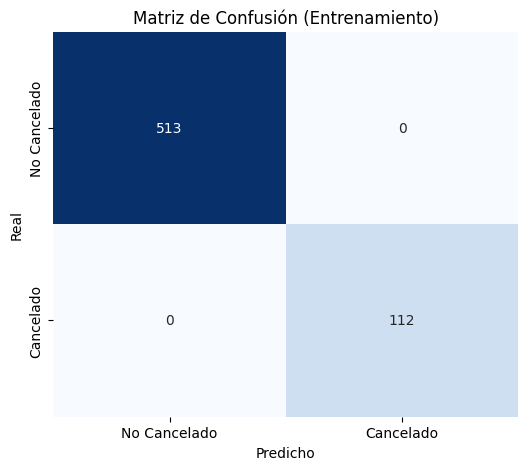


--- Evaluación en el conjunto de PRUEBA ---
Accuracy (Test): 0.8222
Precision (Test): 0.5000
Recall (Test): 0.0417
F1-Score (Test): 0.0769


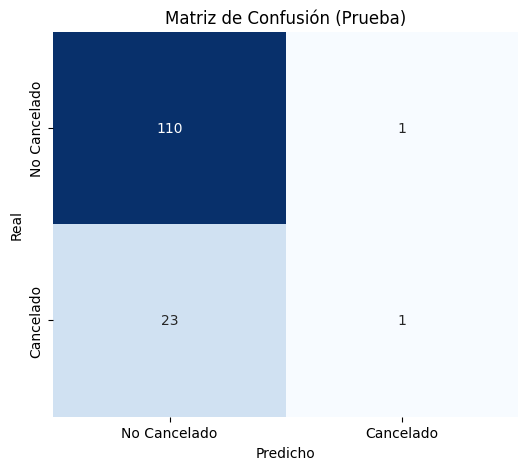

In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# --- Métricas para el conjunto de entrenamiento ---
print("\n--- Evaluación en el conjunto de ENTRENAMIENTO ---")
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
f1_train = f1_score(y_train, y_pred_train)

print(f"Accuracy (Train): {accuracy_train:.4f}")
print(f"Precision (Train): {precision_train:.4f}")
print(f"Recall (Train): {recall_train:.4f}")
print(f"F1-Score (Train): {f1_train:.4f}")

# Matriz de Confusión para Train
cm_train = confusion_matrix(y_train, y_pred_train)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Cancelado', 'Cancelado'], yticklabels=['No Cancelado', 'Cancelado'])
plt.title('Matriz de Confusión (Entrenamiento)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# --- Métricas para el conjunto de prueba ---
print("\n--- Evaluación en el conjunto de PRUEBA ---")
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
f1_test = f1_score(y_test, y_pred_test)

print(f"Accuracy (Test): {accuracy_test:.4f}")
print(f"Precision (Test): {precision_test:.4f}")
print(f"Recall (Test): {recall_test:.4f}")
print(f"F1-Score (Test): {f1_test:.4f}")

# Matriz de Confusión para Test
cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Cancelado', 'Cancelado'], yticklabels=['No Cancelado', 'Cancelado'])
plt.title('Matriz de Confusión (Prueba)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

### ❓ Pregunta 10 — Métricas e interpretación

- ¿Qué métricas has calculado? ¿Por qué esas?
- En este caso de negocio (predecir cancelaciones de un hotel) **¿qué métrica consideras más importante**? ¿`accuracy`, `precision`, `recall` o `f1`? Justifícalo:
  - ¿Qué le cuesta más a un hotel: predecir como "no cancelará" a alguien que sí cancela, o al revés?
- Interpreta la **matriz de confusión**: ¿dónde está cometiendo más errores el modelo?
- ¿Hay indicios de **sobreajuste** (overfitting) al comparar train vs test?


Accuracy,precision,recall o f1 .La accuracy habla de lo bueno que es el modelo,y la precision habla de cuanto acierta el modelo cuando dice que es positivo y recall es al reves de los que fueron positivos cuantos acerto el modelo.F1-Score es la precision balance y recall

predecir que no cancelara cuando si seria mas costoso ya que la habitacion se queda vacia mientras que si predecimos que cancelara y nos equivocamos quiza le tendremos que compensar pero costara mas la habitacion vacia en temporada alta.


El modelo tiene un sobreajuste increible en el entrenamiento, todos los valores son 1 , es un modelo perfecto lo cual es imposible.en la parte de test son valores mucho mas normales, un modelo flojucho pero comparado con uno perfecto tiene mas confianza el split de test

---

## 6. 🎛️ Ajuste de hiperparámetros

Utiliza `GridSearchCV`, `RandomizedSearchCV` o la técnica que consideres oportuna para mejorar el modelo.

> 💡 *No basta con probar todos los valores posibles: explica por qué pones esos valores en el grid.*


In [72]:
# Define un grid de hiperparámetros y búscalo con validación cruzada.



Con este metodo nos podemos tirar horas son 2160 iteraciones, muy exhaustivo pero poco practico.inhabilito el codigo pero lo dejo escrito para que se vea el razonamiento.Voy a usar randomized searchcv.

In [73]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distributions for RandomForestClassifier
# Use scipy.stats distributions for continuous parameters or lists for categorical
param_dist = {
    'n_estimators': randint(100, 500), # Number of trees: random integers between 100 and 500
    'max_features': ['sqrt', 'log2'],   # Number of features to consider for best split
    'max_depth': randint(10, 50),      # Maximum depth of tree: random integers between 10 and 50
    'min_samples_split': randint(2, 20), # Minimum samples required to split a node
    'min_samples_leaf': randint(1, 10),   # Minimum samples required at a leaf node
    'class_weight': [None, 'balanced']  # Handle class imbalance
}

# Instantiate a RandomForestClassifier with a fixed random_state for reproducibility
rf_random = RandomForestClassifier(random_state=42)

# Instantiate RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of solution.
# cv=5 means 5-fold cross-validation
# n_jobs=-1 means use all available processors
# verbose=2 will display progress
# scoring='f1_weighted' is chosen due to class imbalance, providing a balanced measure of precision and recall.
random_search = RandomizedSearchCV(estimator=rf_random, param_distributions=param_dist,
                                   n_iter=50, cv=5, n_jobs=-1, verbose=2,
                                   scoring='f1_weighted', random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\n--- Resultados del RandomizedSearchCV ---")
print("Mejores hiperparámetros encontrados:", random_search.best_params_)
print("Mejor F1-Score (weighted) en validación cruzada:", random_search.best_score_)

# Update the global 'model' variable with the best estimator found by RandomizedSearchCV
model = random_search.best_estimator_
print("\nEl modelo ha sido actualizado con los mejores hiperparámetros encontrados por RandomizedSearchCV.")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

--- Resultados del RandomizedSearchCV ---
Mejores hiperparámetros encontrados: {'class_weight': 'balanced', 'max_depth': 27, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 14, 'n_estimators': 140}
Mejor F1-Score (weighted) en validación cruzada: 0.7651281767001322

El modelo ha sido actualizado con los mejores hiperparámetros encontrados por RandomizedSearchCV.


In [74]:
# Evalúa de nuevo el modelo OPTIMIZADO sobre el test y compáralo con el modelo base.



--- Evaluación del modelo OPTIMIZADO en el conjunto de PRUEBA ---
Accuracy (Test, Optimizado): 0.8000
Precision (Test, Optimizado): 0.2857
Recall (Test, Optimizado): 0.0833
F1-Score (Test, Optimizado): 0.1290


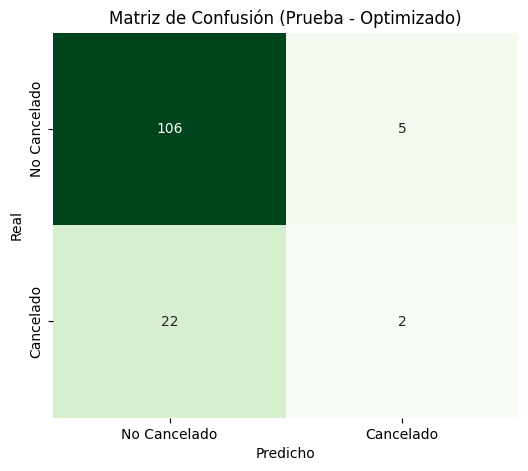


--- Comparación con el modelo BASE en el conjunto de PRUEBA (sin optimizar) ---
Accuracy (Base): 0.8222 vs (Optimizado): 0.8000
Precision (Base): 0.5000 vs (Optimizado): 0.2857
Recall (Base): 0.0417 vs (Optimizado): 0.0833
F1-Score (Base): 0.0769 vs (Optimizado): 0.1290


In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split # Added for train_test_split
from sklearn.preprocessing import OrdinalEncoder # Added for OrdinalEncoder
import numpy as np # Ensure numpy is imported if df['Lead_Time_Dias'].max() is used

# --- Re-execute Data Splitting and Encoding related to Lead_Time_Group to ensure X_train, y_train are defined ---
# This block is copied/adapted from cell xL84ei3zwSDr to fix NameError.
# Assuming 'df' is already preprocessed and globally available from previous steps.

# Define bins_lead_time and labels_lead_time
bins_lead_time = [0, 30, 90, 180, 365, df['Lead_Time_Dias'].max() + 1]
labels_lead_time = ['0-29 días', '30-89 días', '90-179 días', '180-364 días', '365+ días']

# Ensure 'Lead_Time_Group' is created and encoded
if 'Lead_Time_Group' not in df.columns or df['Lead_Time_Group'].dtype != 'category':
    df['Lead_Time_Group'] = pd.cut(df['Lead_Time_Dias'], bins=bins_lead_time, labels=labels_lead_time, right=False)

ordinal_encoder = OrdinalEncoder(categories=[labels_lead_time], dtype=int)
# Check if 'Lead_Time_Group_Encoded' already exists and if its values need updating
if 'Lead_Time_Group_Encoded' not in df.columns or not np.array_equal(df['Lead_Time_Group_Encoded'].values, ordinal_encoder.fit_transform(df[['Lead_Time_Group']]).flatten()):
    df['Lead_Time_Group_Encoded'] = ordinal_encoder.fit_transform(df[['Lead_Time_Group']])

# Prepare X and y
cols_to_drop = ['ID_Reserva', 'Cancelado']
if 'Lead_Time_Group' in df.columns:
    cols_to_drop.append('Lead_Time_Group')

X = df.drop(cols_to_drop, axis=1)
y = df['Cancelado']

# Perform the train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)
# --- End of Data Splitting and Encoding ---


# Recuperar los mejores hiperparámetros encontrados por RandomizedSearchCV
# 'best_params' is available in the kernel state.
best_params = random_search.best_params_

# Crear el modelo optimizado con los mejores hiperparámetros
optimized_model = RandomForestClassifier(random_state=42, **best_params)

# Entrenar el modelo optimizado en el conjunto de entrenamiento completo
optimized_model.fit(X_train, y_train)

# Realizar predicciones con el modelo OPTIMIZADO en el conjunto de prueba
y_pred_test_optimized = optimized_model.predict(X_test)

print("--- Evaluación del modelo OPTIMIZADO en el conjunto de PRUEBA ---")

# Calcular métricas para el modelo optimizado en el conjunto de prueba
accuracy_test_optimized = accuracy_score(y_test, y_pred_test_optimized)
precision_test_optimized = precision_score(y_test, y_pred_test_optimized)
recall_test_optimized = recall_score(y_test, y_pred_test_optimized)
f1_test_optimized = f1_score(y_test, y_pred_test_optimized)

print(f"Accuracy (Test, Optimizado): {accuracy_test_optimized:.4f}")
print(f"Precision (Test, Optimizado): {precision_test_optimized:.4f}")
print(f"Recall (Test, Optimizado): {recall_test_optimized:.4f}")
print(f"F1-Score (Test, Optimizado): {f1_test_optimized:.4f}")

# Matriz de Confusión para el modelo optimizado en Test
cm_test_optimized = confusion_matrix(y_test, y_pred_test_optimized)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_test_optimized, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['No Cancelado', 'Cancelado'], yticklabels=['No Cancelado', 'Cancelado'])
plt.title('Matriz de Confusión (Prueba - Optimizado)')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

print("\n--- Comparación con el modelo BASE en el conjunto de PRUEBA (sin optimizar) ---")
# Se asume que 'accuracy_test', 'precision_test', 'recall_test', 'f1_test'
# del modelo base están disponibles del paso 5.3.
try:
    print(f"Accuracy (Base): {accuracy_test:.4f} vs (Optimizado): {accuracy_test_optimized:.4f}")
    print(f"Precision (Base): {precision_test:.4f} vs (Optimizado): {precision_test_optimized:.4f}")
    print(f"Recall (Base): {recall_test:.4f} vs (Optimizado): {recall_test_optimized:.4f}")
    print(f"F1-Score (Base): {f1_test:.4f} vs (Optimizado): {f1_test_optimized:.4f}")
except NameError:
    print("Las métricas del modelo base no están disponibles directamente. Por favor, asegúrese de haber ejecutado las celdas anteriores.")
    print(f"Aquí tienes las métricas del modelo Optimizado para referencia:")
    print(f"Accuracy (Optimizado): {accuracy_test_optimized:.4f}")
    print(f"Precision (Optimizado): {precision_test_optimized:.4f}")
    print(f"Recall (Optimizado): {recall_test_optimized:.4f}")
    print(f"F1-Score (Optimizado): {f1_test_optimized:.4f}")

### ❓ Pregunta 11 — Ajuste de hiperparámetros

- ¿Qué hiperparámetros has decidido ajustar y por qué esos?
- ¿Qué **rango de valores** has usado en el grid? ¿Por qué?
- ¿Qué **scoring** has elegido para optimizar (`accuracy`, `f1`, `roc_auc`…) y por qué?
- ¿Ha mejorado el modelo? ¿En qué métrica/s y en qué magnitud?


Se han ajustado los pesos de las clases para darle mas peso a las cancelaciones y asi compensar que es una clase minoritaria.El numero de arboles en el bosque se ha parametrizado.Se ha reducido la profundidad de los arboles para reducir el riesgo de sobreajuste.se han reducido las caracteristicas.Han mejorado algunas metricas, mejorando la sensibilidad y el f1 y empeorando lo demas con lo que el modelo predice mejor las cancelaciones reales lo que es mejor para que el hotel no se quede con habitaciones vacias

---

## 7. 🏁 Interpretación final y conclusiones

### ❓ Pregunta 12 — Conclusiones generales

Responde, mínimo, a las siguientes cuestiones:

1. **Resumen del proceso:** ¿Qué pasos has seguido y cuál ha sido la decisión más importante en cada fase?
Se hizo una primera exploracion de los datos, despues de cargar el .csv para entender que tipo de datos habia y hacerse una primera idea, identificar la variable target tambien.Se hizo el EDA (exploratory data analisis) y se pudo observar la relacion de varias variables con el la variable target. se detectaron outliners y inconsistencias por mayusculas/minusculas en en algunas variables.Despues pasamos al preprocesamiento donde se eliminaron duplicados y se normalizaron variables, se rellenaron huecos con valores medios o medianos para no perder datos.Se eliminaron outliners que clarmente eran incorrectos o no aportaban nada(dos reservas de 12000). Se aplico tambien one hot encoding con algunas variables categoricas.No se aplico escalado por el tipo de modelo(random forest).
Se hizo un split del dataset de 70/15/15 para entrenamiento , validacion y test y se estratifico la muestra( se mantuvo la misma proporcion de la target en cada split).Se eligio un randomforest por lo bueno que es con variables tan desvalanceadas.El modelo base se sobreajusto que daba gustito verlo y el modelo posterior mejoro haciendo un randomizedsearchCV con k folds para validacion cruzada.El modelo con los hiperparametros mejoro el rendimiento y no tenia tanto sobreajuste.

2. **Rendimiento final:** ¿El modelo es lo suficientemente bueno como para llevarlo a producción? ¿Por qué?
No tiene suficiente sesibilidad para produccion ,solo acerto 2 de 24 cancelaciones con lo cual 22 habitaciones se quedaron vacias.Aunque el modelo ha mejorado despues de la optimizacion probablemente no sea suficiente para produccion.




3. **Limitaciones:** ¿Qué limitaciones tiene el modelo o los datos? (calidad, tamaño, variables disponibles, sesgos…)

Con tan pocos datos el rendimiento es muy pobre, apenas predice mejor que si dijera siempre que se mantiene la reserva.
Hay un gran desvalance y aunque se ha intentado compensar esto no ha sido suficiente como para que el modelo sea util.El tamaño del dataset es pequeño y cuesta que aprenda patrones complejos.Probablemente falta riqueza a los datos de los clientes o la estancia.

4. **Posibles mejoras:** ¿Cómo intentarías mejorarlo si tuvieras más tiempo / más datos / más recursos? (Más features, otros modelos, técnicas de balanceo, ingeniería de variables, deep learning…)
El dataset podria ser mas grande y permitiria superar el desvalance de clases.se podria analizar la combinacion de variables para enriquecer el modelo.
con mas datos del hotel y datos de clientes se podria generar una prediccion mas robusta.Habria que buscar otros modelos de boosting .maquinas de soporte vectorial podrian funcionar con la clase balanceada.


5. **Valor para el negocio:** ¿Cómo podría Palladium utilizar este modelo para reducir cancelaciones o aumentar ingresos?
El modelo es poco util prediciendo cancelaciones, añadiendo mejoras o cambiando el modelo seria mas util.Toda la parte de analisis de datos sirve para poner de manifiesto que las cancelaciones previas, el canal de reserva, la antelacion de la reserva , tipo de deposito y las peticiones especiales podrian ser buenos indicadores.


> ✏️ Tu respuesta

*Escribe aquí tu justificación.*


---

✅ **Recuerda antes de entregar:**
- [ ] Has rellenado tu nombre y datos en la cabecera.
- [ ] Todas las celdas ejecutan sin errores (kernel reiniciado → *Run All*).
- [ ] **Has justificado por escrito todas las preguntas**, no solo escrito código.
- [ ] El cuaderno se entrega como `.ipynb`.

📨 *Buena suerte y disfruta del proceso. Lo más valioso no es el resultado final del modelo, sino el camino que has tomado para llegar hasta él.*
